# Определение уязвимых групп населения

Задачу, описанную в брифе, поставила молодая НКО, которая хочет помогать малообеспеченным людям. Чтобы делать это эффективно, НКО нужно понять, где живут такие люди, и открыть там свои филиалы.
Кроме того, в НКО хотят выяснить, с какими факторами связана бедность и как эти факторы связаны между собой.

Цель:
* кластеризовать регионы России и определить, какие из них наиболее
остро нуждаются в помощи малообеспеченным/неблагополучным
слоям населения;
* описать группы населения, сталкивающиеся с бедностью;
* определить:
    * влияет ли число детей, пенсионеров и других социально уязвимых
групп на уровень бедности в регионе;
    * связаны ли уровень бедности/социального неблагополучия с
производством и потреблением в регионе;
    * какие ещё зависимости можно наблюдать относительно
социально незащищённых слоёв населения.

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings("ignore")

Для воспроизводимости библиотек

In [2]:
#!pip freeze > requirements.txt

# Версия файла v1.24

- https://rosstat.gov.ru/vpm (vpm_4_2020.xlsx) не нужен
- https://www.fedstat.ru/indicator/30957 (the cost of living 2020.xls) - Прожиточный минимум
- https://www.fedstat.ru/indicator/31554 - Численность пенсионеров (тыс человек )  - the number of pensioners (2016-2021).xls
- https://www.fedstat.ru/indicator/36730 - Среднегодовая численность трудовых ресурсов
- https://www.fedstat.ru/indicator/43701 - Численность населения
- https://www.fedstat.ru/indicator/57316 - Численность пенсионеров (тыс человек ) не использовал
- https://www.fedstat.ru/indicator/61751 - Численность населения субъекта Российской Федерации 2022-2024
- https://www.fedstat.ru/indicator/62582 - Доля детей в общей численности населения percent_of_children.xls


Справочник

In [3]:
names_dict = {
    'агинский бурятский округ': 'Агинский Бурятский округ',
    'алтайский край': 'Алтайский край',
    'амурская область': 'Амурская область',
    'архангельская область': 'Архангельская область',
    'архангельская обл. без данных по ненецкому авт. окр.':  'Архангельская область',
    'архангельская область без автономного округа':  'Архангельская область',
    'архангельская область без\nавтономного округа':  'Архангельская область', 
    'архангельская область без авт. округа':  'Архангельская область', 
    'астраханская область': 'Астраханская область',
    'белгородская область': 'Белгородская область',
    'брянская область': 'Брянская область',
    'владимирская область': 'Владимирская область',
    'bладимирская область': 'Владимирская область',
    'волгоградская область': 'Волгоградская область',
    'bолгоградская область': 'Волгоградская область',
    'вологодская область': 'Вологодская область',
    'bологодская область': 'Вологодская область',
    'воронежская область': 'Воронежская область',
    'bоронежская область': 'Воронежская область',
    'город москва столица российской федерации город федерального значения': 'Москва',
    'город москва': 'Москва',
    'г. москва': 'Москва',
    'г.москва': 'Москва',
    'москва': 'Москва',
    'город санкт-петербург город федерального значения': 'Санкт-Петербург',
    'город санкт-петербург': 'Санкт-Петербург',
    'санкт-петербург': 'Санкт-Петербург',
    'город санкт - петербург': 'Санкт-Петербург',
    'г. санкт-петербург': 'Санкт-Петербург',
    'город федерального значения севастополь': 'Севастополь',
    'город севастополь': 'Севастополь',
    'севастополь': 'Севастополь',
    'г. севастополь': 'Севастополь',
    'еврейская автономная область': 'Еврейская автономная область',
    'еврейская авт. область': 'Еврейская автономная область',
    'забайкальский край': 'Забайкальский край',
    'ивановская область': 'Ивановская область',
    'иркутская область': 'Иркутская область',
    'кабардино-балкарская республика': 'Кабардино-Балкарская Республика',
    'кабардино-балкарская\nреспублика': 'Кабардино-Балкарская Республика',
    'калининградская область': 'Калининградская область',
    'калужская область': 'Калужская область',
    'камчатский край': 'Камчатский край',
    'карачаево-черкесская республика': 'Карачаево-Черкесская Республика',
    'карачаево-черкесская\nреспублика': 'Карачаево-Черкесская Республика',
    'кемеровская область - кузбасс': 'Кемеровская область',
    'кемеровская область – кузбасс': 'Кемеровская область',
    'кемеровская область': 'Кемеровская область',
    'кировская область': 'Кировская область',
    'коми-пермяцкий округ, входящий в состав пермского края': 'Коми-Пермяцкий округ, входящий в состав Пермского края',
    'корякский округ, входящий в состав камчатского края': 'Корякский округ, входящий в состав Камчатского края',
    'костромская область': 'Костромская область',
    'краснодарский край': 'Краснодарский край',
    'красноярский край': 'Красноярский край',
    'курганская область': 'Курганская область',
    'курская область': 'Курская область',
    'ленинградская область': 'Ленинградская область',
    'липецкая область': 'Липецкая область',
    'магаданская область': 'Магаданская область',
    'московская область': 'Московская область',
    'мурманская область': 'Мурманская область',
    'ненецкий автономный округ': 'Ненецкий автономный округ',
    'ненецкий авт. округ': 'Ненецкий автономный округ',
    'hенецкий авт.округ': 'Ненецкий автономный округ',
    'нижегородская область': 'Нижегородская область',
    'hижегородская область': 'Нижегородская область',
    'нижегородская область': 'Нижегородская область',
    'новгородская область': 'Новгородская область',
    'новгородская  область': 'Новгородская область',
    'новосибирская область': 'Новосибирская область',
    'омская область': 'Омская область',
    'оренбургская область': 'Оренбургская область',
    'орловская область': 'Орловская область',
    'пензенская область': 'Пензенская область',
    'пермский край': 'Пермский край',
    'приморский край': 'Приморский край',
    'псковская область': 'Псковская область',
    'республика адыгея': 'Республика Адыгея',
    'республика алтай': 'Республика Алтай',
    'республика башкортостан': 'Республика Башкортостан',
    'республика бурятия': 'Республика Бурятия',
    'республика дагестан': 'Республика Дагестан',
    'республика ингушетия': 'Республика Ингушетия',
    'республика калмыкия': 'Республика Калмыкия',
    'республика карелия': 'Республика Карелия',
    'республика коми': 'Республика Коми',
    'республика крым': 'Республика Крым',
    'республика марий эл': 'Республика Марий Эл',
    'республика мордовия': 'Республика Мордовия',
    'республика саха': 'Республика Саха',
    'республика саха (якутия)': 'Республика Саха',
    'республика северная осетия-алания': 'Республика Северная Осетия-Алания',
    'республика северная осетия - алания': 'Республика Северная Осетия-Алания',
    'республика северная осетия – алания': 'Республика Северная Осетия-Алания',
    'республика северная\nосетия-алания': 'Республика Северная Осетия-Алания',
    'республика северная осетия-алания': 'Республика Северная Осетия-Алания',
    'республика северная осетия- алания': 'Республика Северная Осетия-Алания',
    'республика татарстан': 'Республика Татарстан',
    'республика тыва': 'Республика Тыва',
    'республика хакасия': 'Республика Хакасия',
    'ростовская область': 'Ростовская область',
    'рязанская область': 'Рязанская область',
    'самарская область': 'Самарская область',
    'саратовская область': 'Саратовская область',
    'сахалинская область': 'Сахалинская область',
    'свердловская область': 'Свердловская область',
    'смоленская область': 'Смоленская область',
    'ставропольский край': 'Ставропольский край',
    'таймырский  автономный округ': 'Таймырский автономный округ',
    'тамбовская область': 'Тамбовская область',
    'тверская область': 'Тверская область',
    'томская область': 'Томская область',
    'тульская область': 'Тульская область',
    'тюменская обл.без данных по ханты-мансийскому и ямало-ненецкому авт. окр.': 'Тюменская область',
    'тюменская область без\nавтономных округов':  'Тюменская область',
    'тюменская область без авт. округов': 'Тюменская область',
    'тюменская область': 'Тюменская область',
    'тюменская область без автономного округа': 'Тюменская область', 
    'удмуртская республика': 'Удмуртская Республика',
    'ульяновская область': 'Ульяновская область',
    'усть-ордынский бурятский округ': 'Усть-Ордынский Бурятский округ',
    'хабаровский край': 'Хабаровский край',
    'ханты-мансийский автономный округ - югра': 'Ханты-Мансийский автономный округ',
    'ханты-мансийский автономный округ': 'Ханты-Мансийский автономный округ',
    'ханты-мансийский \nавтономный округ - югра': 'Ханты-Мансийский автономный округ',
    'ханты-мансийский автономный округ –  югра': 'Ханты-Мансийский автономный округ',
    'ханты-мансийский ао': 'Ханты-Мансийский автономный округ',
    'ханты-мансийский авт. округ': 'Ханты-Мансийский автономный округ',
    'ханты-мансийский авт.округ-югра': 'Ханты-Мансийский автономный округ',
    'челябинская область': 'Челябинская область',
    'чеченская республика': 'Чеченская Республика',
    'чувашская республика - чувашия': 'Чувашская Республика',
    'чувашская республика': 'Чувашская Республика',
    'чукотский автономный округ': 'Чукотский автономный округ',
    'чукотский авт. округ': 'Чукотский автономный округ',
    'чукотский авт.округ': 'Чукотский автономный округ',
    'эвенкийский автономный округ': 'Эвенкийский автономный округ',
    'ямало-ненецкий автономный округ': 'Ямало-Ненецкий автономный округ',
    'ямало-ненецкий \nавтономный округ': 'Ямало-Ненецкий автономный округ',
    'Ямало-Ненецкий автономный округ': 'Ямало-Ненецкий автономный округ',
    'ямало-ненецкий авт. округ': 'Ямало-Ненецкий автономный округ',
    'ямало-hенецкий авт.округ': 'Ямало-Ненецкий автономный округ',
    'ямало-hенецкий ао': 'Ямало-Ненецкий автономный округ',
    'ярославская область': 'Ярославская область'
    
    # {'Нижегородская область', 'ямало-hенецкий авт.округ', 'Ханты-Мансийский автономный округ', 'Ямало-Ненецкий автономный округ', 'ханты-мансийский авт.округ-югра'}
}


Библиотечные функции для импортов данных

In [4]:
################################################################################################
#
# Возвращает (симметрическую) разницу множеств индексов датасетов df1 и df2
# 
# Вход: df1, df2 - Датасеты с индексами одинакового типа
# Выход: Множество индексов различий
#
################################################################################################
def сheck_diff_keys( df1, df2 ): 
    set1 = set( df1.index.to_list() )
    set2 = set( df2.index.to_list() )
    print( f"Разница в регонах: {len(set1.symmetric_difference(set2))} шт, {set1.symmetric_difference(set2)}" )
    return set1.symmetric_difference(set2)


################################################################################################
#
# Удаляет из строки выражение в скобках (и их сами), пробелы слева и справа и приводит к нижнему регистру
#
# Вход: s - Строка
# Выход: Строка
# Пример: " 123aBC(456 cvb) 780  " ==> (123abc 780)
#
################################################################################################
def process_subj( s ):
    s = re.sub( r'[\(].*?[\)]', r'', s ).strip()
    return s.strip().lower()


################################################################################################
#
# Предобработка датафрейма
# 
# Датафрейм проходит этапы предобработки:
# 1) Удаляются строки, заданное поле которых с пропуском или среди заданного списка значений
#      - имеет пропуск
#      - среди заданного списка строк
#      - содержит хотя бы 1 подстроку из списка в формате строки
# 2) Удаляет пробелы справа и слева и приводит текст к нижнему регистру
# 3) Выкусывает из получившейся строки выражение в скобках (сключая сами скобки)
# 4) Заменяет строку, которая осталась строкой из справочника 
#
# Вход:
#    df - Датафрейм
#    col - название поля, подлежащего обработке
#    key_drop - список строк, с которыми при попадании col гарантирует удаление строки из датафрейма
#    rows_drop_if_all_cols_null - список имен полей датафрейма, гарантируется удаление строки из датафрейма, если все поля списка имеют пропуск
#
# Выход: очищенный датафрейм
#
################################################################################################
def preprocess_df( df, col = 'region', key_drop = None, rows_drop_if_all_cols_null = None ):
    # Удалим ключи согласно списку
    if key_drop is None:
        key_drop = []   
    df = df[~df[col].isin(key_drop)].copy()
    
    # Удалим пустые стороки
    df = df[ ~df[col].isna() ].copy()
    
    # Удаляем строки с NaN в столбцах key_check_null при наличии хотя бы 1 пропуска
    if rows_drop_if_all_cols_null is not None and len( rows_drop_if_all_cols_null ) > 0:
        df.dropna( subset = rows_drop_if_all_cols_null, inplace = True, axis = 0, how = 'all' )    
        
    # убираем строки содержащие "Российская Федерация", федеральный округ и район
    df = df[ ~df[col].str.contains('федеральный округ|Федерация|район|Байконур|в старых границах|УТ МВД по')].copy()          

    # Выкусываем скобки
    df[col] = df[col].apply( lambda x: process_subj( x ) )
        
    # Заменяем на словарные значения
    df[col] = df[col].apply( lambda x: names_dict.get( x, x ) ) 
    
    return df 


################################################################################################
#
# Заполняет пропуски из ближайшего заполненного поля года слева, затем справа.
# Требуется, чтобы датафрейм имел непрерывную цепочку полей года а диапазоне [syear, eyear + 1]
#
# Вход: 
#    df - Датафрейм, подлежащий обработке
#    syear - Номер года минимальный
#    eyear - Номер года максимальный
#    direction = True - Заполнять данными из ближайшего года слева и, если не найдено, то справа
#                False - Наоборот 
#
# Выход: Датафрейм с заполненными пропусками
#
################################################################################################
def fill_nan_tymeset_df( df, syear, eyear, direction = True ):
    if( direction ):
        # Заменяем пропуск из предыдущего года, движемся направо
        for year in range( syear + 1, eyear + 1):
            df[str(year)] = df[str(year)].combine_first(df[ str( year - 1 ) ])
            
        # Заменяем пропуск из слулующего года, движемся налево
        for year in range( eyear - 1, syear - 1, -1):
            df[str(year)] = df[str(year)].combine_first( df[ str( year + 1 ) ])
    else:
        # Заменяем пропуск из слулующего года, движемся налево
        for year in range( eyear - 1, syear - 1, -1):
            df[str(year)] = df[str(year)].combine_first( df[ str( year + 1 ) ])

        # Заменяем пропуск из предыдущего года, движемся направо
        for year in range( syear + 1, eyear + 1):
            df[str(year)] = df[str(year)].combine_first(df[ str( year - 1 ) ])

    return df


################################################################################################
#
# Удаляет дубликаты строк датафрейма.
#
# Вход: df - Датафрейм
# Выход: Датафрейм без дублей
#
################################################################################################
def drop_dublicates( df ):
    cnt_dubles = df[ df.duplicated() ].shape[0]
    if cnt_dubles > 0:
        df = df.drop_duplicates()
        print( f'Удалено дубликатов: {cnt_dubles}' )

    return df

    
################################################################################################
#
# Преобразует строку в число.
#
# Вход: 
#    s - Строка
#    precission - точность округления, 0 - вернется цлое число, > 0 - вещественное
#
# Выход: Число
#
################################################################################################
def to_num( s, precission = 1 ):
    try:
        if isinstance( s, str ):
            s = re.sub( r'[^\d,]', '', s )
        num = round( float(s), precission )
        return num
    
    except ValueError:
        return np.nan    
    
    
################################################################################################
#
# Печатает топ 3 повторяющихся ключей и их уникальное количество.
#
# Вход: df - датафрейм
#
################################################################################################
def print_index( df ):
    print( "Топ 3 повторов ключей:" )
    print( "----------------------" )
    print( df.index.value_counts().nlargest( 3 ) )
    print( f'\nКоличество ключей: {df.index.nunique()}' )  


################################################################################################
#
# Графически отобратить датафрейм через barplot
#
# Вход: 
#    df - датафрейм
#    x, y - Отображаемый признак по оси x, y
#    label_x,label_y - Подписи по осям x, y
#    rotation - Унро поворота подписей по оси x
#    hdr - Заголовок
#    figsize - Размер графика
#    legend - Печатать легенду (True) или нет (False)
#    print_val - Печатать (True) или нет (False) численное значение над barplot
#    hue - Признак для цветовой раскраски
#
################################################################################################
def plot_bar_df( df, x, y, figsize = (24,5), hdr = '', label_x = '', label_y = '', rotation = 0, legend = False, print_val = True, hue = None ):
    tmp_df = df.copy()
    fig = plt.figure( figsize = figsize )
    fig = sns.barplot( data = tmp_df, x = x, y = y, hue = hue, palette='rainbow', legend = legend, log_scale = False )
    
    plt.title( hdr, fontsize = 14 )
    plt.xlabel( label_x )
    plt.ylabel( label_y )
    plt.xticks(rotation = rotation );   
    
    plt.grid() 
    
    if print_val:
        for container in fig.containers:
            fig.bar_label(container)    
        
    plt.show()


################################################################################################
#
# Графически отобратить датафрейм через lineplot
#
# Вход: 
#    df - датафрейм
#    x, y - Отображаемый признак по оси x, y
#    hue - Признак для цветовой раскраски
#    label_x,label_y - Подписи по осям x, y
#    hdr - Заголовок
#    figsize - Размер графика
#    rotation - Унро поворота подписей по оси x
#
################################################################################################
def plot_line_df( df, x, y, hue, label_x, label_y, hdr, figsize = (24,5), rotation = 0 ):
    fig, ax = plt.subplots( figsize = figsize )
    fig = sns.lineplot( data = df, x = x, y = y, hue = hue )
    fig.set_yticklabels(ax.get_yticklabels(), rotation = rotation)
    fig.grid()
    plt.xlabel( label_x )
    plt.ylabel( label_y )
    plt.title( hdr )
    plt.show()

### Предварительный план подготовки объединенного датасета
1) Читаем данные
2) Проводим нормирование (Для объективнсти оценок пространство признаков будут сделаны нормированным безразмерными)

### 1. Численность населения по регионам и федеральным округам на 1 января каждого года за 1999–2022 гг.
- Единица измерения - количество человек. 
- Особенность: Данные с нарастающим итогом
- Будет использоваться для нормировки многих показателей с размерностью количества
- Источник данных: предоставленный архив в проекте задания

In [5]:
fname = 'social_russia_data/population.xlsx'
df = pd.read_excel( fname, skiprows = 1, usecols = 'A:Z', skipfooter = 0).rename( columns = {'Unnamed: 0': 'region', 'Unnamed: 1': 'ОКТМО'} )
df = drop_dublicates( df )
df.head( 5 )

,region,ОКТМО,январь 1999 г.,январь 2000 г.,январь 2001 г.,январь 2002 г.,январь 2003 г.,январь 2004 г.,январь 2005 г.,январь 2006 г.,...,январь 2013 г.,январь 2014 г.,январь 2015 г.,январь 2016 г.,январь 2017 г.,январь 2018 г.,январь 2019 г.,январь 2020 г.,январь 2021 г.,январь 2022 г.
0,все население,w2:p_mest:11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Российская Федерация,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Раздел 1. Муниципальные образования субъектов ...,00000000000,147539426.0,146890128.0,146303611.0,145649334.0,144963650.0,144333586.0,143801046.0,143236582.0,...,143347059.0,143666931.0,146267288.0,146544710.0,146804372.0,146880432.0,146780720.0,146748590.0,146171015.0,145557576.0
3,Центральный федеральный округ,030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Раздел 1. Муниципальные образования субъектов ...,00000000000,38311159.0,38227656.0,38175094.0,38068452.0,37946810.0,37965073.0,38044068.0,38109006.0,...,38678913.0,38819874.0,38951479.0,39104319.0,39209582.0,39311413.0,39378059.0,39433556.0,39250960.0,39104400.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   region          368 non-null    object 
 1   ОКТМО           368 non-null    object 
 2   январь 1999 г.  97 non-null     float64
 3   январь 2000 г.  97 non-null     float64
 4   январь 2001 г.  97 non-null     float64
 5   январь 2002 г.  97 non-null     float64
 6   январь 2003 г.  90 non-null     float64
 7   январь 2004 г.  94 non-null     float64
 8   январь 2005 г.  94 non-null     float64
 9   январь 2006 г.  94 non-null     float64
 10  январь 2007 г.  94 non-null     float64
 11  январь 2008 г.  94 non-null     float64
 12  январь 2009 г.  94 non-null     float64
 13  январь 2010 г.  94 non-null     float64
 14  январь 2011 г.  94 non-null     float64
 15  январь 2012 г.  94 non-null     float64
 16  январь 2013 г.  94 non-null     float64
 17  январь 2014 г.  94 non-null     flo

Проверим пропуски

In [7]:
df.isna().sum().sum()

np.int64(5656)

Пропуски есть, обработаем позже после обработки. Большинство или все связаны со сдвигом на 1 строку названия регионов и данных.

Предобработка данных

In [8]:
# Особенность файла - ранные региона сдвинуты на 1 строку с данными. Совместим строку
for ind in df.loc[df['ОКТМО'] == '00000000000', 'region'].index:
    df.loc[ind, 'region'] = df.loc[ ind - 1, 'region' ]
    
# Удалим пробелы в названиях регионов
df['region'] = df['region'].str.strip()

# Удалим строки с пустыми значениями, они идут с кодом 00000000000
df = df[df['ОКТМО'] == '00000000000'].drop( columns = ['ОКТМО'] ).set_index( 'region' )

# Извлечем год из строковой даты
df.columns = [ re.sub( rf"\D", "", col )for col in df.columns.to_list() ]

# Удалим индекс
df.reset_index( inplace = True )

# Список для удалений строк 
key_drop = [
    'Архангельская область', 
    'Тюменская область', 
    'Москва в старых границах'
]   

cols_itog = [ str( x ) for x in range( 2015, 2021 ) ]
df = preprocess_df( df, key_drop = key_drop, rows_drop_if_all_cols_null = cols_itog  ).set_index( 'region' ).sort_index()
df

,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
region,,,,,,,,,,,,,,,,,,,,,
Алтайский край,2662738.0,2651628.0,2641079.0,2621050.0,2602595.0,2571987.0,2539430.0,2503510.0,2473024.0,2453455.0,...,2398751.0,2390638.0,2384812.0,2376774.0,2365680.0,2350080.0,2332813.0,2317153.0,2296353.0,2268179.0
Амурская область,949526.0,935607.0,923055.0,911381.0,901044.0,887781.0,874018.0,861056.0,850502.0,844290.0,...,816910.0,811274.0,809873.0,805689.0,801752.0,798424.0,793194.0,790044.0,781846.0,772525.0
Архангельская область,NaN,NaN,NaN,NaN,NaN,1273668.0,1257312.0,1239924.0,1224813.0,1215264.0,...,1159506.0,1148760.0,1139950.0,1130240.0,1121813.0,1111031.0,1100290.0,1092424.0,1082662.0,1069782.0
Астраханская область,1016372.0,1012385.0,1009281.0,1005510.0,1004780.0,1006073.0,1006467.0,1002517.0,1001300.0,1005897.0,...,1013840.0,1016516.0,1021287.0,1018626.0,1018866.0,1017514.0,1014065.0,1005782.0,997778.0,989430.0
Белгородская область,1494868.0,1501699.0,1506976.0,1508137.0,1511899.0,1513860.0,1511662.0,1511715.0,1514153.0,1520102.0,...,1540985.0,1544108.0,1547936.0,1550137.0,1552865.0,1549876.0,1547418.0,1549151.0,1541259.0,1531917.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Чеченская Республика,1159839.0,1110237.0,996427.0,1072867.0,1105378.0,1116910.0,1133172.0,1152335.0,1171975.0,1196920.0,...,1324767.0,1346438.0,1370268.0,1394172.0,1414865.0,1436981.0,1456951.0,1478726.0,1497992.0,1516387.0
Чувашская Республика,1338819.0,1334219.0,1327743.0,1319498.0,1311737.0,1301632.0,1291065.0,1278903.0,1268614.0,1263016.0,...,1243431.0,1239984.0,1238071.0,1236628.0,1235863.0,1231117.0,1223395.0,1217818.0,1207875.0,1198429.0
Чукотский автономный округ,67010.0,61613.0,57534.0,55309.0,53137.0,51933.0,51815.0,52391.0,52913.0,52825.0,...,50780.0,50555.0,50540.0,50157.0,49822.0,49348.0,49663.0,50288.0,49527.0,50040.0


Проверим повторно на пропуски

In [9]:
df[df.isna().mean( axis = 1 ) > 0]

,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
region,,,,,,,,,,,,,,,,,,,,,
Архангельская область,NaN,NaN,NaN,NaN,NaN,1273668.0,1257312.0,1239924.0,1224813.0,1215264.0,...,1159506.0,1148760.0,1139950.0,1130240.0,1121813.0,1111031.0,1100290.0,1092424.0,1082662.0,1069782.0
Республика Крым,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1895915.0,1907106.0,1912168.0,1913731.0,1911818.0,1912622.0,1901578.0,1896393.0
Севастополь,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,398973.0,416263.0,428753.0,436670.0,443212.0,449138.0,509992.0,522057.0
Тюменская область,NaN,NaN,NaN,NaN,NaN,1317268.0,1311562.0,1308653.0,1309889.0,1315355.0,...,1385008.0,1409426.0,1429232.0,1454626.0,1477903.0,1498779.0,1518695.0,1537416.0,1543389.0,1552148.0


Заполним пропуски из ближайших левых или правых (если нет левых) столбцов признаков

In [10]:
df = fill_nan_tymeset_df( df, 1999, 2022 )

df[df.isna().mean( axis = 1 ) > 0]

,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
region,,,,,,,,,,,,,,,,,,,,,


Сделаем поля целочисленными

In [11]:
df = df.astype( 'int64' )
df.head( 3 )

,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
region,,,,,,,,,,,,,,,,,,,,,
Алтайский край,2662738,2651628,2641079,2621050,2602595,2571987,2539430,2503510,2473024,2453455,...,2398751,2390638,2384812,2376774,2365680,2350080,2332813,2317153,2296353,2268179
Амурская область,949526,935607,923055,911381,901044,887781,874018,861056,850502,844290,...,816910,811274,809873,805689,801752,798424,793194,790044,781846,772525
Архангельская область,1273668,1273668,1273668,1273668,1273668,1273668,1257312,1239924,1224813,1215264,...,1159506,1148760,1139950,1130240,1121813,1111031,1100290,1092424,1082662,1069782


Проверим уникальность и количество ключей

In [12]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


85 регионов

#### Вычислим прирост за год

In [13]:
cols = df.columns[:-1]

# Абсолютный показатель на начало года (будет нормирующим показателем)
df_population = df[cols].copy() 

# Абсолютный прирост за год 
df_population_model = pd.DataFrame( index = df.index, data = (df_population.values[:, 1:] - df_population.values[:, :-1]), columns = cols[:-1] )


#### Готовим данные для объединенного датасета

In [14]:
df_population_model_norm = df_population['2021'].to_frame().rename( columns = { '2021': "population_norm" } )
df_population_model_norm

,population_norm
region,
Алтайский край,2296353
Амурская область,781846
Архангельская область,1082662
Астраханская область,997778
Белгородская область,1541259
...,...
Чеченская Республика,1497992
Чувашская Республика,1207875
Чукотский автономный округ,49527


#### Посмотрим динамику

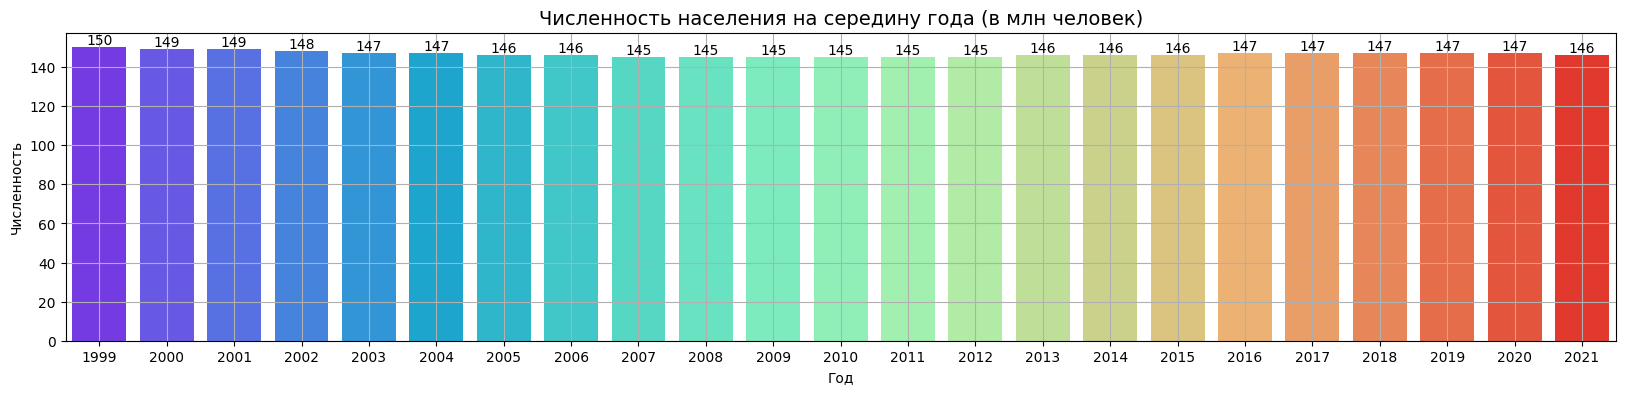

In [15]:
tmp_df = df_population_model
label_y = "Численность"
label_x = 'Год'

tmp_df = (df_population.sum() / 1000000).round().astype( 'int' ).reset_index()
tmp_df.columns = [label_x, label_y]

hdr = "Численность населения на середину года (в млн человек)" 

plot_bar_df( df = tmp_df, x = label_x, y = label_y, label_x = label_x, label_y = label_y, hdr = hdr, figsize = (20,4) )

Видим спад до 2013г и с 2020г. 

Посмотрим прирост в 2013 (2 региона добавились) и в 2020 годах

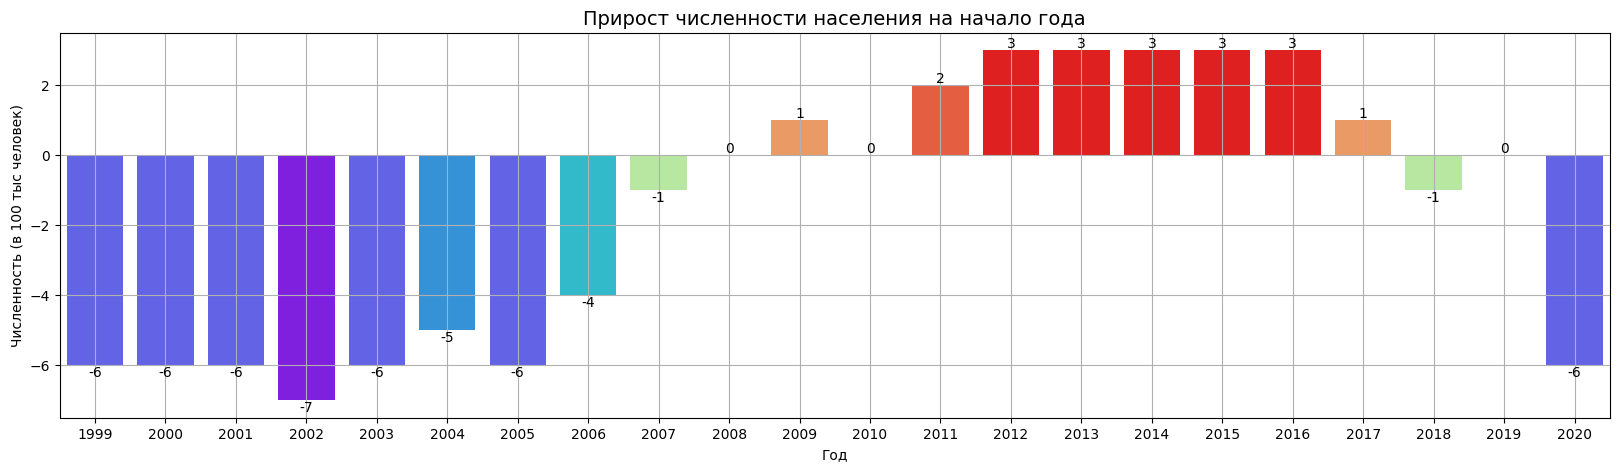

In [16]:
label_y = "Численность"
label_x = 'Год'

tmp_df = (df_population_model.sum() / 100000).round().astype( 'int' ).reset_index()
tmp_df.columns = [label_x, label_y]

hdr = "Прирост численности населения на начало года" 

plot_bar_df( df = tmp_df, x = label_x, y = label_y, label_x = label_x, label_y = label_y + ' (в 100 тыс человек)', hdr = hdr, figsize = (20,5),hue = label_y )

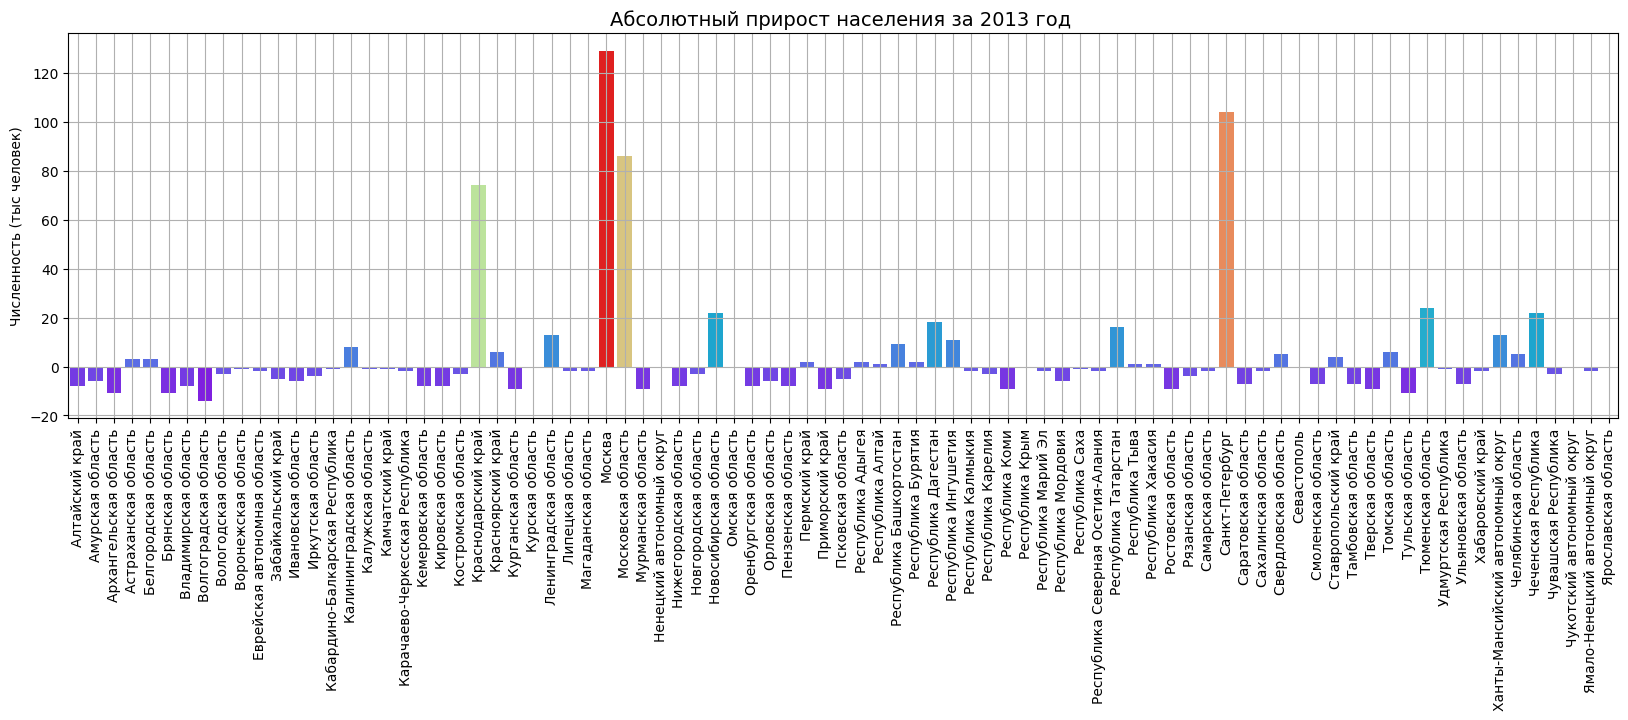

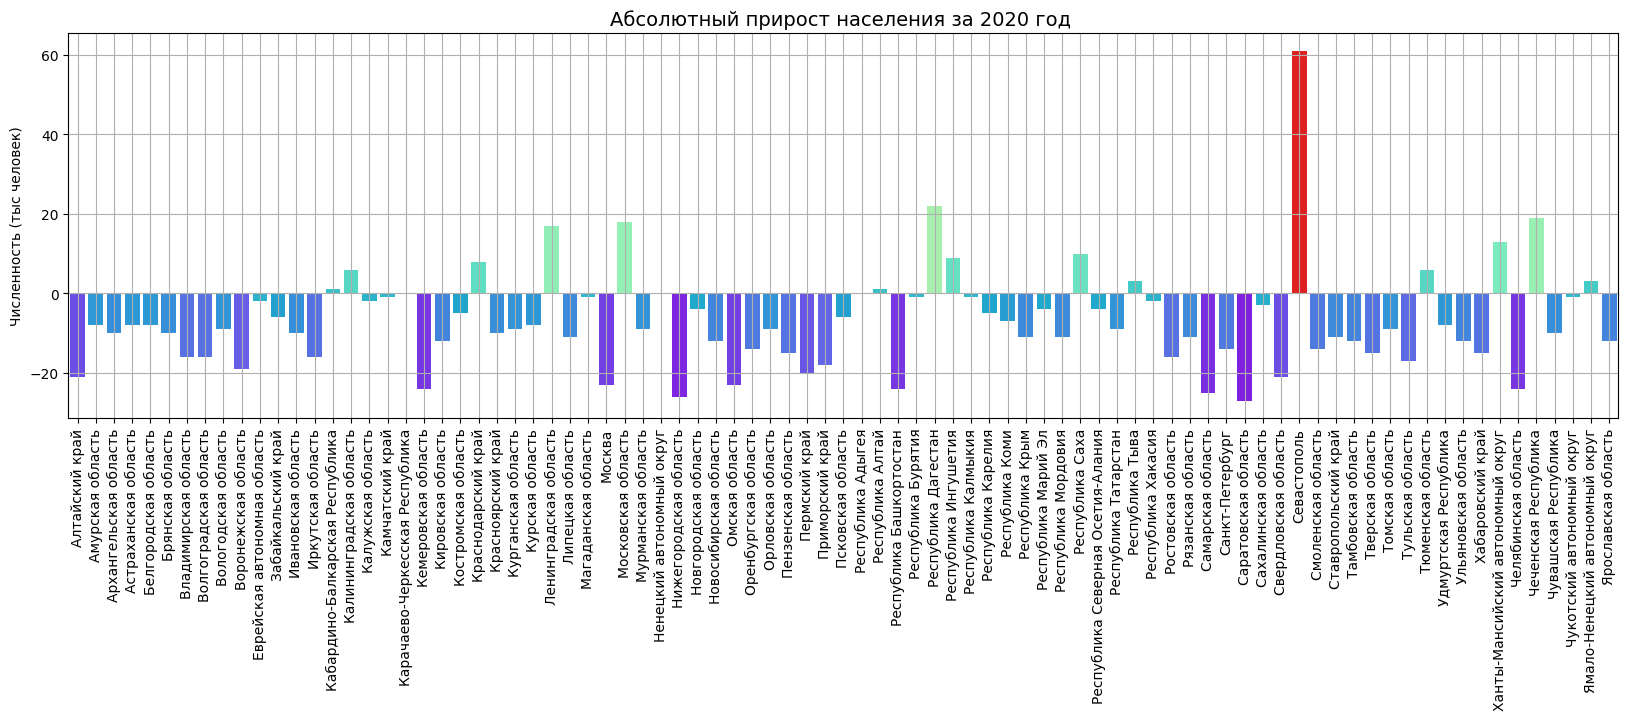

In [17]:
years = ['2013', '2020']
tmp_df = (df_population_model.loc[:, years ] / 1000).round().astype( 'int' ).sort_index()

for year in years:
    hdr = f"Абсолютный прирост населения за {year} год " 
    plot_bar_df( df = tmp_df, x = tmp_df.index, y = year, rotation = 90, hdr = hdr , label_y = 'Численность (тыс человек)', print_val = False, figsize = (20,5), hue = year )

Показатели в целом падают. 

### 2. Прожиточный минимум на 4 квартал 2020г

- Единица измерения: рубли
- Особенность: данные в абсолютном исчислении на год (без нарастания итога)
- Будет использоваться для нормирования показателей в рублевом исчислении
- Источник: [Федеральная служба государственной статистики](https://www.rosstat.gov.ru/vpm)

Читаем данные и делаем первичную предобработку

In [18]:
fname = 'social_russia_data/vpm_4_2020.xlsx'
df = pd.read_excel( fname, skiprows = 4, usecols = 'A:E', skipfooter = 0, sheet_name = '4 kv_2020').rename( columns = {
    'Unnamed: 0': 'region', 
    'Unnamed: 1': 'cost_of_living_all', 
    'трудоспособное население': 'cost_of_living_work',
    'пенсионеры': 'cost_of_living_retired', 
    'дети': 'cost_of_living_child' 
} )

# Удалим дубликаты (если есть)
df = drop_dublicates( df )

# Приведем к словарю, почистив пустые строки в важных для нас признаках
df = preprocess_df( df = df, rows_drop_if_all_cols_null = ['cost_of_living_all', 'cost_of_living_work', 'cost_of_living_retired', 'cost_of_living_child'] ).set_index( 'region' ).sort_index( ascending = True )
df.head( 5 )

,cost_of_living_all,cost_of_living_work,cost_of_living_retired,cost_of_living_child
region,,,,
Алтайский край,10211.0,10904.0,8715.0,10349.0
Амурская область,13530.0,14331.0,10884.0,14387.0
Архангельская область,13304.0,14507.0,11042.0,12965.0
Астраханская область,10793.0,11287.0,8998.0,11547.0
Белгородская область,9593.0,10403.0,8024.0,9435.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Алтайский край to Ярославская область
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cost_of_living_all      85 non-null     float64
 1   cost_of_living_work     85 non-null     float64
 2   cost_of_living_retired  85 non-null     float64
 3   cost_of_living_child    85 non-null     float64
dtypes: float64(4)
memory usage: 3.3+ KB


Смотрим пропуски

In [20]:
df.isna().sum()

cost_of_living_all        0
cost_of_living_work       0
cost_of_living_retired    0
cost_of_living_child      0
dtype: int64

Пропусков нет. Смотрим статистику

In [21]:
df.describe()

,cost_of_living_all,cost_of_living_work,cost_of_living_retired,cost_of_living_child
count,85.000000,85.000000,85.000000,85.000000
mean,12037.364706,12856.247059,9776.035294,12251.000000
std,3006.844303,3144.740673,2291.637574,3185.404972
min,9053.000000,9834.000000,7602.000000,8895.000000
25%,10324.000000,10930.000000,8369.000000,10434.000000
50%,10962.000000,11760.000000,8998.000000,11060.000000
75%,12084.000000,12943.000000,9712.000000,12511.000000
max,23999.000000,24711.000000,18524.000000,24668.000000


Приведен к целочисленному типу, т.к. данные целые (хоть и в вещественном виде)

In [22]:
df = df.astype( 'int64' )

Проверим количество и уникальность индекса

In [23]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


85 Регионов

Готовим данные для модели. 

In [24]:
df_cost_of_living_model_norm = df.copy()

Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [25]:
_ = сheck_diff_keys( df_cost_of_living_model_norm, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 3. Число умерших на первом году жизни детей за год
- Единица измерения: количество человек, значение показателя за год
- Особенность: данные в абсолютном исчислении за год (без нарастания итога)
- Берем суммарные данные по городской и сельской статистике. 
- Источник - Предоставленные данные к проекту

In [26]:
################################################################################################
# preprocess_df_mortality - Читает файл, делает первичную предобработку и возвразает набор данных
#
# Входные данные:
#    fname - Путь к xls файлу
#    rows_drop_if_all_cols_null - Признаки, которые должны быть полностью заполнены
#
# Выходные данные:
#    df - Набор данных
#
################################################################################################
def preprocess_df_mortality( fname, rows_drop_if_all_cols_null = None ):
    df = pd.read_excel( fname, skiprows = 2, skipfooter = 13, usecols = 'A, D:AI' ).rename( columns = { 'Unnamed: 0': 'region', 'Unnamed: 1': "terr" } )
    
    df = drop_dublicates( df ).set_index( 'region' )

    # Учтем особенности отчетности по 2м регионам
    df.loc['            Архангельская область (кроме Ненецкого автономного округа)'] = \
        df.loc['        Архангельская область'] - \
        df.loc['            Ненецкий автономный округ (Архангельская область)'] 
    
    df.loc['            Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)'] = \
        df.loc['        Тюменская область'] - \
        df.loc['            Ханты-Мансийский автономный округ - Югра (Тюменская область)'] - \
        df.loc['            Ямало-Ненецкий автономный округ (Тюменская область)']    
    
    # Список для удалений строк 
    key_drop = [
        '        Архангельская область', 
        '        Тюменская область', 
    ]    
    
    df.reset_index( inplace = True )
    
    df = preprocess_df( df = df, key_drop = key_drop, rows_drop_if_all_cols_null = rows_drop_if_all_cols_null )
    
    # Заполняем пропуски ближайшими слева или (если слева нет) 
    df = fill_nan_tymeset_df( df, 1990, 2021 ).set_index( 'region' ).sort_index( ascending = True )

    # Приведем поля к целому типу
    df = df.round().astype( 'int64' )

    return df

Обработаем регионы 
- Исключение скобок
- Замена по словарю
- Сортировка и удаление строк с отсутствующими данными по всех полях 2015 и выше
- Заполнение пропусков из ближайшего левого (а если нет такового - из ближайшего заполненного правого признака-года)

In [27]:
cols_itog = [ str( x ) for x in range( 2015, 2021 ) ]

fname = 'social_russia_data/child_mortality_rural_1990_2021.xls'
df_child_mortality_rural = preprocess_df_mortality( fname, rows_drop_if_all_cols_null = cols_itog )
display( df_child_mortality_rural.head(3) )

fname = 'social_russia_data/child_mortality_urban_1990_2021.xls'
df_child_mortality_urban = preprocess_df_mortality( fname, rows_drop_if_all_cols_null = cols_itog )
display( df_child_mortality_urban.head(3) )

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
region,,,,,,,,,,,,,,,,,,,,,
Алтайский край,217,245,230,249,226,261,220,213,176,196,...,173,154,117,94,87,79,70,60,44,42
Амурская область,142,124,106,108,111,99,100,118,86,91,...,63,50,39,31,23,20,17,16,13,15
Архангельская область,105,108,82,91,74,56,60,42,49,51,...,31,29,29,25,17,22,14,16,5,10


,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
region,,,,,,,,,,,,,,,,,,,,,
Алтайский край,305,322,299,311,271,229,185,162,164,195,...,157,136,158,128,124,106,106,54,53,46
Амурская область,201,169,174,136,131,151,145,150,160,179,...,98,69,62,52,30,28,29,27,29,21
Архангельская область,183,166,163,146,150,150,134,115,118,117,...,77,84,68,59,62,50,39,42,24,22


In [28]:
print( df_child_mortality_urban.shape, df_child_mortality_rural.shape )

(85, 32) (85, 32)


Смотрим пропуски

In [29]:
display( df_child_mortality_urban[ df_child_mortality_urban.isna().mean( axis = 1 ) > 0] )
display( df_child_mortality_rural[ df_child_mortality_rural.isna().mean( axis = 1 ) > 0] )

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
region,,,,,,,,,,,,,,,,,,,,,


,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
region,,,,,,,,,,,,,,,,,,,,,


Пропусков нет

In [30]:
display( df_child_mortality_urban.info() )


<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Алтайский край to Ярославская область
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1990    85 non-null     int64
 1   1991    85 non-null     int64
 2   1992    85 non-null     int64
 3   1993    85 non-null     int64
 4   1994    85 non-null     int64
 5   1995    85 non-null     int64
 6   1996    85 non-null     int64
 7   1997    85 non-null     int64
 8   1998    85 non-null     int64
 9   1999    85 non-null     int64
 10  2000    85 non-null     int64
 11  2001    85 non-null     int64
 12  2002    85 non-null     int64
 13  2003    85 non-null     int64
 14  2004    85 non-null     int64
 15  2005    85 non-null     int64
 16  2006    85 non-null     int64
 17  2007    85 non-null     int64
 18  2008    85 non-null     int64
 19  2009    85 non-null     int64
 20  2010    85 non-null     int64
 21  2011    85 non-null     int64
 22  2012    85 non-null     int

None

In [31]:
display( df_child_mortality_rural.info() )

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Алтайский край to Ярославская область
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1990    85 non-null     int64
 1   1991    85 non-null     int64
 2   1992    85 non-null     int64
 3   1993    85 non-null     int64
 4   1994    85 non-null     int64
 5   1995    85 non-null     int64
 6   1996    85 non-null     int64
 7   1997    85 non-null     int64
 8   1998    85 non-null     int64
 9   1999    85 non-null     int64
 10  2000    85 non-null     int64
 11  2001    85 non-null     int64
 12  2002    85 non-null     int64
 13  2003    85 non-null     int64
 14  2004    85 non-null     int64
 15  2005    85 non-null     int64
 16  2006    85 non-null     int64
 17  2007    85 non-null     int64
 18  2008    85 non-null     int64
 19  2009    85 non-null     int64
 20  2010    85 non-null     int64
 21  2011    85 non-null     int64
 22  2012    85 non-null     int

None

Объединяем датафреймы

In [32]:
df = df_child_mortality_urban.add( df_child_mortality_rural )

# Повторно проверим на пропуски
display( df[ df.isna().sum( axis = 1 ) > 0] )

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
region,,,,,,,,,,,,,,,,,,,,,


Пропусков нет. Проверим неповторяемось, количество ключей и смотрим статистику

In [33]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


85 регионов

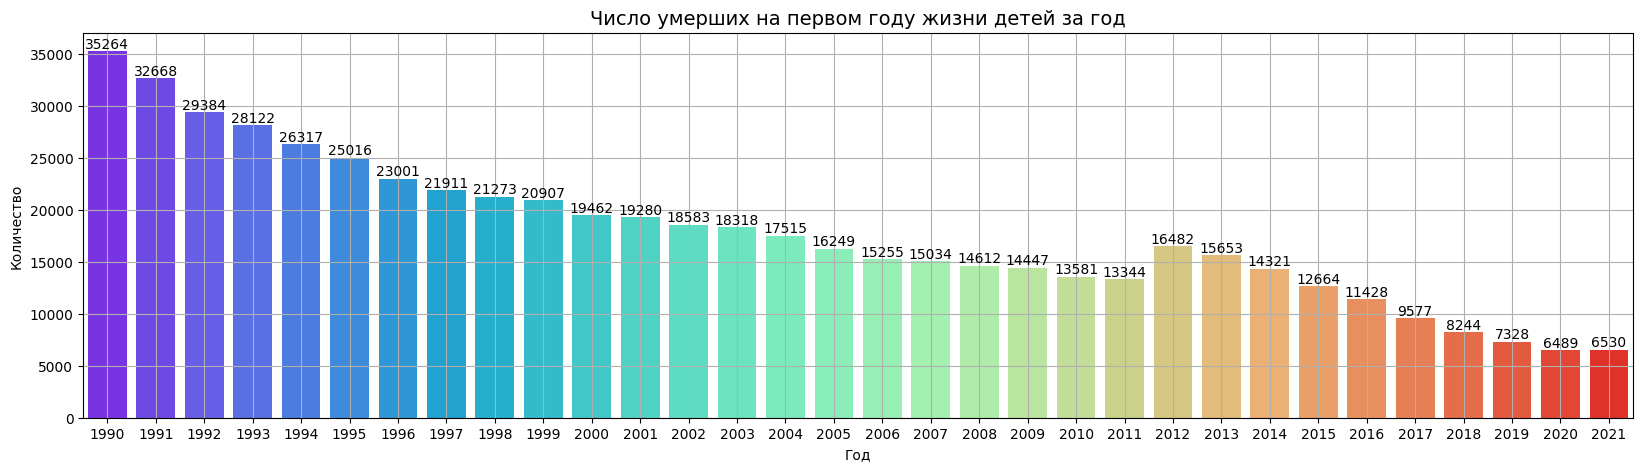

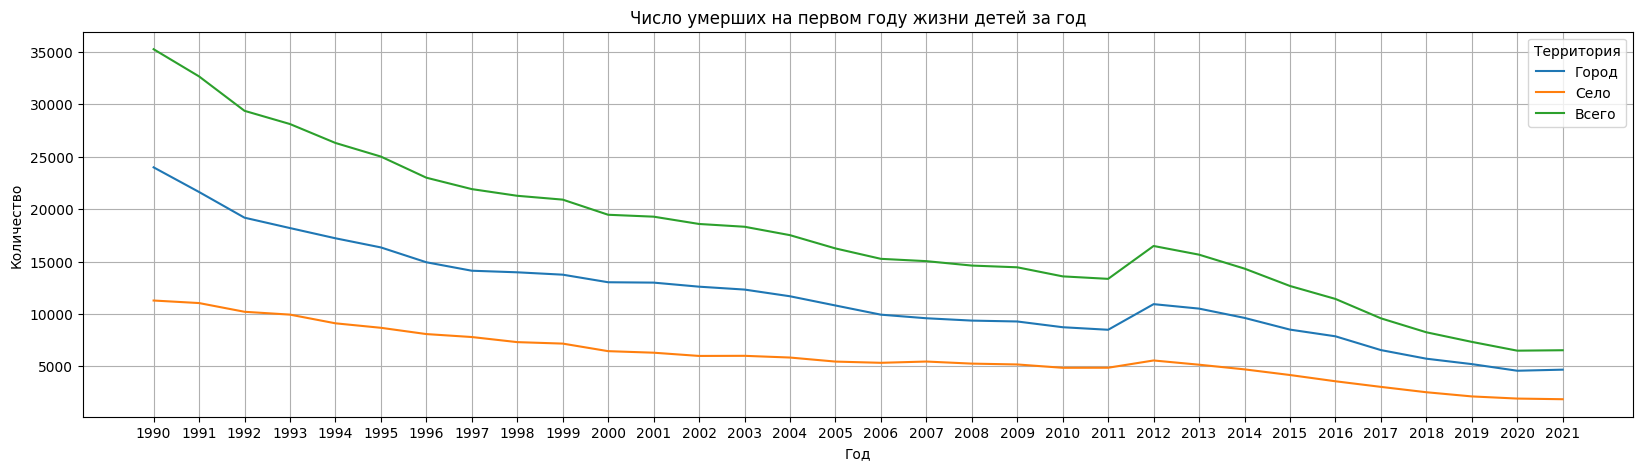

In [34]:
cols = df.columns #cols_itog
tmp_df1 = df_child_mortality_urban[ cols ].stack().reset_index().rename( columns = { "level_1": "year", 0: "Количество"} ).groupby( 'year' )['Количество'].sum().round().astype( 'int64' ).to_frame()
tmp_df2 = df_child_mortality_rural[ cols ].stack().reset_index().rename( columns = { "level_1": "year", 0: "Количество"} ).groupby( 'year' )['Количество'].sum().round().astype( 'int64' ).to_frame()
tmp_df3 = tmp_df1.add( tmp_df2 )

tmp_df1['Территория'] = 'Город' 
tmp_df2['Территория'] = 'Село'
tmp_df3['Территория'] = 'Всего'
tmp_df = pd.concat( [tmp_df1, tmp_df2, tmp_df3], axis = 0 )

hdr = "Число умерших на первом году жизни детей за год" 
figsize = (20,5)
label_y = "Количество"
label_x = 'Год'
    
plot_bar_df( df = tmp_df3, x = 'year', y = label_y,  label_x = "Год", label_y = label_y, hdr = hdr, figsize = figsize )
plot_line_df( df = tmp_df, x = tmp_df.index, y = label_y, hue = 'Территория', label_x = 'Год', label_y = label_y, hdr = hdr, figsize = figsize )

Детская смертность устойчиво в целом падает

Готовим данные для объединенного датасета

In [35]:
df_child_mortality_model = df['2020'].to_frame().rename( columns = { '2020': "child_mortality" } )

Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [36]:
_ = сheck_diff_keys( df_child_mortality_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 4. Число людей с инвалидностью по регионам, по месяцам, по возрастным группам.

- Единица измерения - количество человек. 
- Особенность: Данные приводятся с нарастанием итога 
- Источник - Предоставленные данные к проекту

Таблица содержит данные по месяцам и для разных возрастов, берем данные на 1 января каждого года по непенсионным (до 60 лет) возрастам: количество инвалидов пожилого возраста может зависеть, в том, числе, от естественного старения. Инвалидность среди трудоспособного населения дает более точную оценку социального неблагополучия региона.  

In [37]:
# Читаем данные
fname = 'social_russia_data/disabled_total_by_age_2017_2022.csv'
df = pd.read_csv( fname ).rename( columns = { 'date': 'year' } )

# Преобразуем в дату
df['year'] = pd.to_datetime( df['year'], format='%Y-%m-%d' ) 

# Удалим дубли строк
df = drop_dublicates( df )

# Смотрим
df.head()

,region,total,18_30,31_40,41_50,51_60,60_,year
0,Российская Федерация,11640873.0,550895.0,766054.0,1030652.0,2135436.0,7157836.0,2017-01-01
1,Центральный федеральный округ,3420310.0,118579.0,172662.0,257484.0,598102.0,2273483.0,2017-01-01
2,Белгородская область,223030.0,6318.0,10383.0,16596.0,37444.0,152289.0,2017-01-01
3,Брянская область,110418.0,4215.0,6568.0,10230.0,21481.0,67924.0,2017-01-01
4,Владимирская область,133352.0,4454.0,6811.0,9606.0,23322.0,89159.0,2017-01-01


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6080 entries, 0 to 6079
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   region  6080 non-null   object        
 1   total   6074 non-null   float64       
 2   18_30   6073 non-null   float64       
 3   31_40   6074 non-null   float64       
 4   41_50   6074 non-null   float64       
 5   51_60   6074 non-null   float64       
 6   60_     6074 non-null   float64       
 7   year    6080 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 380.1+ KB


Статистика

In [39]:
df.describe().round()

,total,18_30,31_40,41_50,51_60,60_,year
count,6074.0,6073.0,6074.0,6074.0,6074.0,6074.0,6080
mean,352459.0,15893.0,24841.0,33100.0,59917.0,218711.0,2019-08-16 17:59:59.999999744
min,275.0,23.0,25.0,39.0,70.0,107.0,2017-01-01 00:00:00
25%,57696.0,2676.0,4226.0,5809.0,10528.0,33310.0,2018-04-23 12:00:00
50%,103309.0,4074.0,6549.0,9209.0,16823.0,63968.0,2019-08-16 12:00:00
75%,209703.0,9387.0,14692.0,19989.0,35444.0,128016.0,2020-12-08 18:00:00
max,11640873.0,550895.0,796087.0,1079846.0,2135436.0,7157836.0,2022-04-01 00:00:00
std,1202536.0,53690.0,83734.0,111874.0,204203.0,752562.0,NaN


Смотрим пропуски

In [40]:
df[ df.isna().mean( axis = 1 ) > 0]

,region,total,18_30,31_40,41_50,51_60,60_,year
419,Ставропольский край,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-01
424,Краснодарский край,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-01
455,Алтайский край,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-01
460,Красноярский край,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-01
465,Хабаровский край,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-01
473,Приморский край,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-01
2089,г. Байконур,275.0,NaN,27.0,50.0,75.0,123.0,2018-10-01


Отработаем пропуски

In [41]:
# Удалим пустые строки
df.dropna( thresh = 3, inplace = True, axis = 0 )

# Заполним недостающие данные
df.fillna( {'18_30': df['total'] - df['31_40'] - df['41_50'] - df['51_60'] - df['60_']}, inplace = True )

# Повторно смотрим пропуски
df[ df.isna().sum( axis = 1 ) > 0 ]

,region,total,18_30,31_40,41_50,51_60,60_,year


Предобработка

In [42]:
# Добавим признак - трудоспособная часть населения (18-60 лет)
df["work"] = df['18_30'] + df['31_40'] + df['41_50'] + df['51_60']

# Удалим не нужные данные
df.drop( columns = ['18_30','31_40','41_50','51_60'], inplace = True )

# Отфильтруем данные на начало года
df = df[ df['year'].dt.month == 1 ].copy()
df['year'] = df['year'].dt.year

# Удалим ключи федерального уровня, пустые ключи и преобразуем к словарю
df = preprocess_df( df = df )

df.head(3)

,region,total,60_,year,work
2,Белгородская область,223030.0,152289.0,2017,70741.0
3,Брянская область,110418.0,67924.0,2017,42494.0
4,Владимирская область,133352.0,89159.0,2017,44193.0


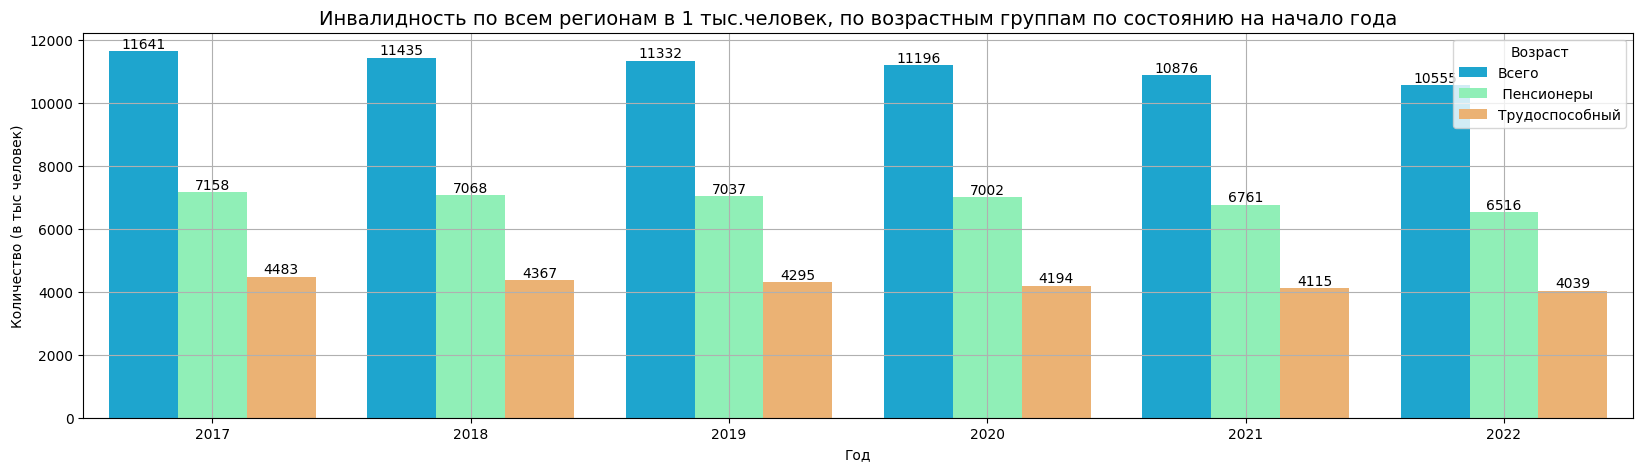

In [43]:
tmp_df = (df.groupby( 'year' )[['total', '60_', 'work']].sum() / 1000)\
    .rename( columns = { "total": "Всего", "60_": " Пенсионеры", "work": "Трудоспособный" } )\
    .round().stack().reset_index()\
    .rename( columns = {'level_1':'Возраст', 0:"Значение"} ).set_index( 'year' )

plot_bar_df( df = tmp_df, x = tmp_df.index, y = 'Значение', hue = 'Возраст', figsize = (20,5), hdr = 'Инвалидность по всем регионам в 1 тыс.человек, по возрастным группам по состоянию на начало года', label_x = 'Год', label_y = 'Количество (в тыс человек)', print_val = True, legend = True )

Наблюдается тенденция к уменьшению с годами в абсолютном выражении

Готовим данные для объединенного датасета

In [44]:
cols = ['region','total','60_','work']
key_cols = 'region'

# На начало 2021 (=конец 2020)
tmp_df1 = df.loc[ df['year'] == 2021, cols ].copy().set_index( key_cols ).astype( 'int64' )

# На начало 2020 (=конец 2019)
tmp_df2 = df.loc[ df['year'] == 2020, cols ].copy().set_index( key_cols ).astype( 'int64' )

# Дельта за 2020 = На начало 2021 - На начало 2020
tmp_df3 = tmp_df1 - tmp_df2

# Переименуем колонки
tmp_df1.columns = ['disabled_total','disabled_60_','disabled_work']
tmp_df3.columns = ['disabled_delta_total','disabled_delta_60_','disabled_delta_work']

df_disabled_model = tmp_df1.sort_index()
df_disabled_model

,disabled_total,disabled_60_,disabled_work
region,,,
Алтайский край,167330,107520,59810
Амурская область,62153,38004,24149
Архангельская область,82868,56370,26498
Астраханская область,42770,23379,19391
Белгородская область,191552,133344,58208
...,...,...,...
Чеченская Республика,173524,28982,144542
Чувашская Республика,74970,46496,28474
Чукотский автономный округ,1620,560,1060


Проверим неповторяемось, количество ключей и смотрим статистику

In [45]:
print_index( df_disabled_model )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


85 Регионов

Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [46]:
_ = сheck_diff_keys( df_disabled_model, df_population_model_norm )


Разница в регонах: 0 шт, set()


### 5. Заболеваемость на 100 тыс.человек населения, по возрастным группам и группам заболеваний.

Заболеваемость с диагнозом, установленным впервые в жизни, проживающих в районе обслуживания лечебного учреждения, на 100 тыс.человек населения
- Уже дана относительная величина, годная для сравнения по регионам внутри заданной категории возраста
- Но мы не можем отследивать тенденцию по годам - требуются абсолютнве величины
- Источник - Предоставленные данные к проекту

Методика расчета:
Рассчитывается как производное числа зарегистрированных больных с впервые в жизни установленным диагнозом, умноженного на 100000, деленного на численность населения на конец года.

In [47]:
# Читаем данные и делаем первичную обработку
fname = 'social_russia_data/morbidity_2005_2020_age_disease.xls'
df = pd.read_excel( fname, header = 2, usecols = 'A,:O' ).rename( columns = { "Unnamed: 0": "region", "Unnamed: 1": "Заболевание", "Unnamed: 2": "Возраст" } )
df.head()

,region,Заболевание,Возраст,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Российская Федерация,"Беременность, роды и послеродовой период",0-14 лет,21.3,17.6,17.9,22.1,18.1,18.9,16.2,17.7,12.2,12.1,8.1,15.5
1,Российская Федерация,"Беременность, роды и послеродовой период",15-17 лет,1537.3,1527.5,1605.2,1681.5,1618.9,1451.3,1247.6,1229.1,1272.3,1186.5,914.0,794.0
2,Российская Федерация,"Беременность, роды и послеродовой период",18 лет и старше,6731.7,6833.5,7229.7,7516.9,8007.5,8084.4,7981.6,8141.8,8084.6,8219.9,7734.1,7278.6
3,Российская Федерация,"Беременность, роды и послеродовой период",Всего,5719.4,5861.2,6258.7,6556.6,7011.6,7085.3,6979.7,7121.5,7067.6,7145.3,6700.2,6291.1
4,Российская Федерация,Болезни глаза и его придаточного аппарата,0-14 лет,5643.4,5581.1,5760.8,5775.9,5743.6,5884.8,5931.9,6206.9,6104.5,5919.4,5910.3,5971.5


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8159 entries, 0 to 8158
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   region       8159 non-null   object 
 1   Заболевание  8159 non-null   object 
 2   Возраст      8159 non-null   object 
 3   2005         6348 non-null   float64
 4   2006         6348 non-null   float64
 5   2007         6348 non-null   float64
 6   2008         6348 non-null   float64
 7   2009         6348 non-null   float64
 8   2010         6348 non-null   float64
 9   2011         6348 non-null   float64
 10  2012         5980 non-null   float64
 11  2013         6348 non-null   float64
 12  2014         6460 non-null   float64
 13  2015         6117 non-null   float64
 14  2016         6110 non-null   float64
dtypes: float64(12), object(3)
memory usage: 956.3+ KB


Статистика

In [49]:
df.describe()

,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
count,6348.000000,6348.000000,6348.000000,6348.000000,6348.000000,6348.000000,6348.000000,5980.000000,6348.000000,6460.000000,6117.000000,6110.000000
mean,11788.723897,12281.674212,12546.121219,12650.523960,13671.820526,13322.288689,13609.108223,14334.689682,13570.043636,12641.105031,13757.187723,13869.818183
std,29915.767204,31226.879920,31985.938797,32270.113745,35498.931218,34433.133738,35438.788351,35944.423454,34862.114657,32903.019928,34279.872644,34821.175142
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1047.000000,1153.700000,1163.100000,1168.075000,1167.875000,1120.500000,996.475000,1249.750000,1108.125000,1285.325000,1255.600000,1200.250000
50%,2854.000000,2996.700000,3019.250000,3010.000000,3013.700000,2998.400000,2911.550000,3189.500000,3005.550000,3296.700000,3042.300000,2968.300000
75%,5962.400000,6169.475000,6342.575000,6491.000000,6578.000000,6642.350000,6626.200000,7127.225000,6665.000000,7023.825000,6629.700000,6460.825000
max,306401.600000,322149.500000,346146.700000,345619.800000,383126.400000,373361.900000,368374.300000,372318.200000,358529.600000,328771.000000,316082.200000,301686.200000


Предобработка. Нас интересуют 2015-2016 годы

In [50]:
# Устраним дубликаты
df = drop_dublicates( df )

# Приведем к словарю, удалив строки с пропусками в 2015 и 2016 годах
df = preprocess_df( df, key_drop = None, rows_drop_if_all_cols_null = ['2015','2016'] )

df = df[['region','Заболевание','Возраст','2015','2016']]

df.head()

,region,Заболевание,Возраст,2015,2016
146,Белгородская область,"Беременность, роды и послеродовой период",0-14 лет,5.9,0.0
147,Белгородская область,"Беременность, роды и послеродовой период",15-17 лет,1221.4,875.6
148,Белгородская область,"Беременность, роды и послеродовой период",18 лет и старше,5551.7,5567.6
149,Белгородская область,"Беременность, роды и послеродовой период",Всего,4879.2,4868.6
150,Белгородская область,Болезни глаза и его придаточного аппарата,0-14 лет,5841.5,6187.0


Смотрим пропуски

In [51]:
df.isna().sum().sum()

np.int64(0)

Пропусков нет. Посмотрим уникальные значения 

In [52]:
df['Заболевание'].value_counts()

Заболевание
Беременность, роды и послеродовой период                                        340
Болезни глаза и его придаточного аппарата                                       340
Психические расстройства и расстройства поведения                               340
Новообразования                                                                 340
Некоторые инфекционные и паразитарные болезни                                   340
Все заболевания                                                                 340
Врожденные аномалии (пороки развития), деформации и хромосомные нарушения       340
Болезни эндокринной системы, расстройства питания и нарушения обмена веществ    340
Болезни уха и сосцевидного отростка                                             340
Болезни системы кровообращения                                                  340
Болезни органов пищеварения                                                     340
Болезни органов дыхания                                         

In [53]:
df['Возраст'].value_counts()

Возраст
0-14 лет           1445
15-17 лет          1360
18 лет и старше    1360
Всего              1360
Name: count, dtype: int64

Возьмем интегральные показатели

In [54]:
df = df.loc[(df['Заболевание'] == 'Все заболевания') & (df['Возраст'] == 'Всего'), ['region', '2015','2016']]
df.head()

,region,2015,2016
193,Белгородская область,70736.1,74637.4
266,Брянская область,78206.2,77439.0
339,Владимирская область,93765.7,94163.6
412,Воронежская область,54555.4,55009.9
485,Ивановская область,87753.9,88473.5


Готовим данные для объединенного датасета

In [55]:
df_morbidity_model = df[['region', '2016']].set_index( 'region' ).rename( columns = { '2016': 'morbidity' } )
df_morbidity_model.head()

,morbidity
region,
Белгородская область,74637.4
Брянская область,77439.0
Владимирская область,94163.6
Воронежская область,55009.9
Ивановская область,88473.5


Финальная статистика

In [56]:
df_morbidity_model.describe()

,morbidity
count,85.000000
mean,79982.394118
std,17440.366421
min,44792.000000
25%,67012.900000
50%,77439.000000
75%,89949.900000
max,138231.700000


Проверим неповторяемось, количество ключей и смотрим статистику

In [57]:
print_index( df_morbidity_model )

Топ 3 повторов ключей:
----------------------
region
Белгородская область    1
Пензенская область      1
Челябинская область     1
Name: count, dtype: int64

Количество ключей: 85


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [58]:
_ = сheck_diff_keys( df_morbidity_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 6. Процент людей, живущих за чертой бедности

Численность населения с денежными доходами ниже величины прожиточного минимума, в процентах от общей численности населения
- Единицы измерения: процент
- Особенность: Относительная величина, складывать нельзя, но сравнивать можно
- Источник - Предоставленные данные к проекту


**Методика расчета**
Численность населения с денежными доходами ниже величины прожиточного минимума определяется на основе данных о распределении населения по величине среднедушевых денежных доходов и является результатом их соизмерения с величиной прожиточного минимума; в процентах от общей численности населения.

Данные до 2012 г. включительно рассчитаны с использованием величины макроэкономического показателя среднедушевых денежных доходов населения, определенной в соответствии с


Читаем данные

In [59]:
fname = 'social_russia_data/poverty_percent_by_regions_1992_2020.csv'
df = pd.read_csv( fname )
df.head( 3 )

,region,year,poverty_percent
0,Российская Федерация,1992,33.5
1,Российская Федерация,1993,31.3
2,Российская Федерация,1994,22.4


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2339 entries, 0 to 2338
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           2339 non-null   object 
 1   year             2339 non-null   int64  
 2   poverty_percent  2339 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 54.9+ KB


In [61]:
df.describe()

,year,poverty_percent
count,2339.000000,2339.000000
mean,2007.799487,20.236597
std,7.434428,13.357606
min,1992.000000,0.000000
25%,2002.000000,12.500000
50%,2008.000000,17.300000
75%,2014.000000,25.500000
max,2020.000000,98.400000


In [62]:
df.isna().mean()

region             0.0
year               0.0
poverty_percent    0.0
dtype: float64

Пропусков нет. Посмотрим по "сырым" данных динамику по РФ в целом

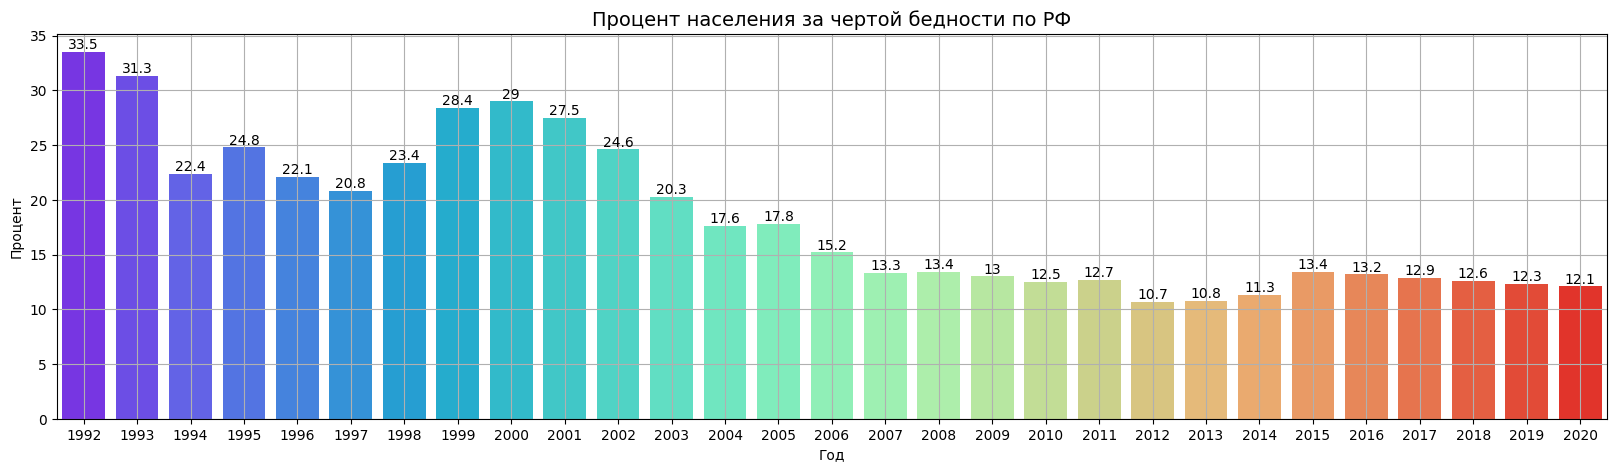

In [63]:
plot_bar_df( df = df[df['region'] == 'Российская Федерация'], x = 'year', y = 'poverty_percent', hue = None, figsize = (20,5), hdr = 'Процент населения за чертой бедности по РФ', label_x = 'Год', label_y = 'Процент', print_val = True, legend = False )

В целом процент снижается, но зависимость сложная

#### Предобработка

In [64]:
# Почистим дубли строк
df = drop_dublicates( df )

# Приведем к справочнику территории
key_drop = [
    '        Архангельская область',
    '        Тюменская область'
]

# Приведем к словарю
df = preprocess_df( df, key_drop = key_drop ).set_index( 'region' ).sort_index()
df.head(3)

,year,poverty_percent
region,,
Алтайский край,2004,30.9
Алтайский край,1997,45.7
Алтайский край,1998,52.9


Готовим данные для объединенного датасета

In [65]:
df_poverty_percent = df.copy()
df_poverty_percent_model = df.loc[ df['year'] == 2020, ['poverty_percent'] ]

Проверим неповторяемось, количество ключей и смотрим статистику

In [66]:
print_index( df_poverty_percent_model )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [67]:
_ = сheck_diff_keys( df_poverty_percent_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 7. Расходы на социальную политику от общих расходов бюджета региона, % в год
- Единицы измерения: процент
- Особенность: Относительная величина, складывать нельзя, но сравнивать можно
- Источник - Предоставленные данные к проекту

In [68]:
fname = 'social_russia_data/welfare_expense_share_2015_2020.xlsx'
df = pd.read_excel(fname)
df.head()

,region,2015,2016,2017,2018,2019,2020
0,Российская Федерация,15.8,16.6,20.4,20.3,19.8,21.3
1,Центральный\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
2,Белгородская область,11.3,11.8,16.4,15.6,13.8,16.1
3,Брянская область,22.0,26.6,24.7,23.7,20.7,23.1
4,Владимирская область,18.1,18.0,24.0,23.4,23.4,26.0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  94 non-null     object 
 1   2015    86 non-null     float64
 2   2016    86 non-null     float64
 3   2017    86 non-null     float64
 4   2018    86 non-null     float64
 5   2019    86 non-null     float64
 6   2020    86 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.3+ KB


Посмотрим по "сырым" данным динамику по РФ в целом

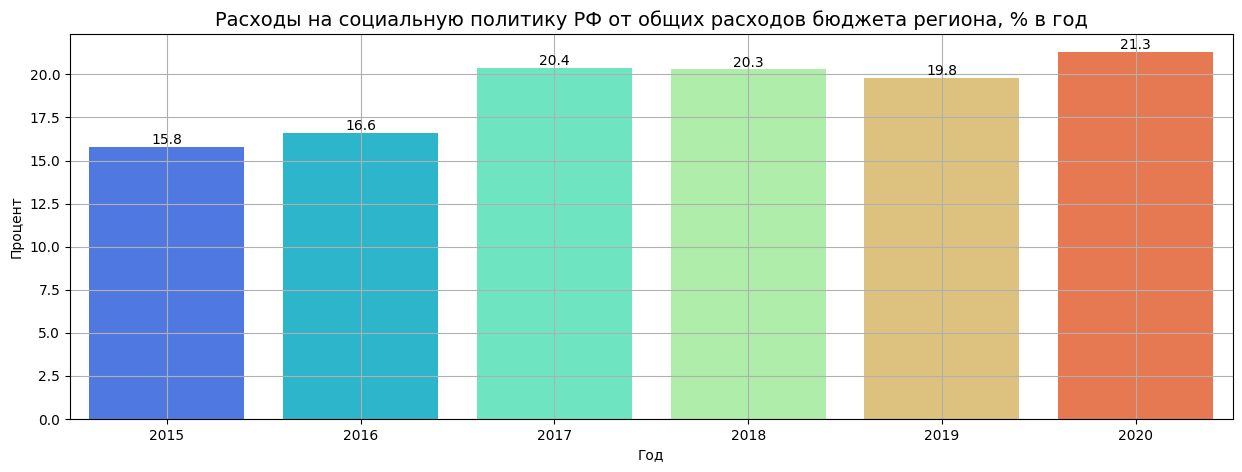

In [70]:
tmp_df = df.loc[df['region'] == 'Российская Федерация'].set_index('region').unstack().to_frame().reset_index().rename( columns = { "level_0": "Год", 0:"Процент" } )

plot_bar_df( df = tmp_df, x = 'Год', y = 'Процент', hue = None, figsize = (15,5), hdr = 'Расходы на социальную политику РФ от общих расходов бюджета региона, % в год', label_x = 'Год', label_y = 'Процент', print_val = True, legend = False )

В целом показатель растет

Проверим и заполним пропуски

In [71]:
df.isna().mean()

region    0.000000
2015      0.085106
2016      0.085106
2017      0.085106
2018      0.085106
2019      0.085106
2020      0.085106
dtype: float64

In [72]:
df[df.isna().mean( axis = 1 ) > 0]

,region,2015,2016,2017,2018,2019,2020
1,Центральный\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
20,Северо-Западный\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
32,Южный\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
41,Северо-Кавказский\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
49,Приволжский\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
64,Уральский\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
71,Сибирский\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN
82,Дальневосточный\n федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN


Заполним пропуски

In [73]:
# Удаляем пустые строким
df.dropna( thresh = 2, axis = 0, inplace = True )

# Повторно смотрим пропуски
df[df.isna().mean( axis = 1 ) > 0]

,region,2015,2016,2017,2018,2019,2020


#### Предобработка данных

In [74]:
# Чистим дубли
df = drop_dublicates( df )

# Заменяем на словарное значение территорию
df = preprocess_df( df ).set_index( 'region' ).sort_index()

Смотрим количество и уникальность ключей

In [75]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Смотрим количество и уникальность ключей

In [76]:
df.describe().round( 1 )

,2015,2016,2017,2018,2019,2020
count,85.0,85.0,85.0,85.0,85.0,85.0
mean,15.9,17.1,23.0,22.3,21.0,22.9
std,3.1,4.5,5.0,4.8,4.5,5.2
min,6.4,6.5,7.8,7.0,4.7,6.4
25%,13.8,15.1,21.4,20.9,19.2,21.6
50%,16.2,16.8,24.2,23.4,22.0,23.5
75%,18.1,18.8,25.9,25.4,23.8,25.7
max,22.0,29.1,30.9,29.8,29.5,35.1


Готовим данные для объединенного датасета

In [77]:
df_welfare = df.copy()

col = 2020
df_welfare_model = df[ col ].to_frame().rename( columns = { col: 'welfare'} )
df_welfare_model

,welfare
region,
Алтайский край,29.7
Амурская область,21.7
Архангельская область,21.4
Астраханская область,31.4
Белгородская область,16.1
...,...
Чеченская Республика,35.1
Чувашская Республика,24.9
Чукотский автономный округ,6.4


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [78]:
_ = сheck_diff_keys( df_welfare_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 8. Среднедушевые и реальные денежные доходы населения, номинальная и реальная начисленная зарплата, по регионам
- Относительная величина, можно сравнивать по регионам
- Источник - Предоставленные данные к проекту

In [79]:
################################################################################################
#
# Входные данные:
#    fname - Путь к xls
#    sheet_name - Номер читаемого листа файла
#
# Выходные данные:
#    df - Датафрейм
#
################################################################################################
def preprocess_cash_real_income( fname, sheet_name ):
    df = pd.read_excel( fname, sheet_name = sheet_name )
    
    # Удаляем пустые строки
    df.dropna( thresh = 2, axis = 0, inplace = True )

    # Удаляем дубли и делаем индекс
    df = drop_dublicates( df )    

    # Приводим ключи к словарю
    key_drop = [
        'Архангельская область',
        'Тюменская область'
    ]
    
    # Приведем к словарю
    df = preprocess_df( df, key_drop = key_drop ).set_index( 'region' ).sort_index()
        
    # Исправляем ошибки ввода. Надо выкусить нечисловые символы и преобразовать в число
    for col in df.columns.to_list():
        df[col] = df[col].apply( lambda s: to_num( s ) )
            
    return df


Читаем файл с предобработкой

In [80]:
fname = 'social_russia_data/cash_real_income_wages_2015_2020.xlsx'

df_per_capita = preprocess_cash_real_income( fname = fname, sheet_name = 0 ) 
df_formal_wage = preprocess_cash_real_income( fname = fname, sheet_name = 2 ) 

display( 'Номинальный доход на душу населения', df_per_capita.head( 2 ) )
display( 'Номинальная зарплата', df_formal_wage.head( 2 ) )

'Номинальный доход на душу населения'

,2015,2016,2017,2018,2019,2020
region,,,,,,
Алтайский край,20860.0,21256.0,22139.0,22829.0,23937.0,23864.0
Амурская область,28240.0,27976.0,29213.0,30937.0,33304.0,35499.0


'Номинальная зарплата'

,2015,2016,2017,2018,2019,2020
region,,,,,,
Алтайский край,20090.0,21202.0,22743.0,25519.0,27962.0,30072.0
Амурская область,32902.0,33837.0,37368.0,42315.0,47234.0,52430.0


Приведем к целочисленному типу данных (они и так целочисленных, хоть и хранятся в вещественном формате)

In [81]:
df_per_capita = df_per_capita.astype( 'int64' )
df_formal_wage = df_per_capita.astype( 'int64' )

In [82]:
display( 'Номинальный доход на душу населения' )
df_per_capita.info()
display( 'Номинальная зарплата' )
df_formal_wage.info()

'Номинальный доход на душу населения'

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Алтайский край to Ярославская область
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2015    85 non-null     int64
 1   2016    85 non-null     int64
 2   2017    85 non-null     int64
 3   2018    85 non-null     int64
 4   2019    85 non-null     int64
 5   2020    85 non-null     int64
dtypes: int64(6)
memory usage: 4.6+ KB


'Номинальная зарплата'

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Алтайский край to Ярославская область
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2015    85 non-null     int64
 1   2016    85 non-null     int64
 2   2017    85 non-null     int64
 3   2018    85 non-null     int64
 4   2019    85 non-null     int64
 5   2020    85 non-null     int64
dtypes: int64(6)
memory usage: 4.6+ KB


Проверим пропуски

In [83]:
display( 'Номинальный доход на душу населения', df_per_capita[df_per_capita.isna().mean( axis = 1) > 0] )
display( 'Номинальная зарплата', df_formal_wage[df_formal_wage.isna().mean( axis = 1) > 0] )

'Номинальный доход на душу населения'

,2015,2016,2017,2018,2019,2020
region,,,,,,


'Номинальная зарплата'

,2015,2016,2017,2018,2019,2020
region,,,,,,


Просмотрим динамику по годам

In [84]:
df_per_capita['type'] = 'per_capita'
df_formal_wage['type'] = 'formal_wage'

df_cash =  pd.concat( [
        df_per_capita,
        df_formal_wage,
    ],
    axis = 0
).sort_index()

df_cash.head()

,2015,2016,2017,2018,2019,2020,type
region,,,,,,,
Алтайский край,20860,21256,22139,22829,23937,23864,per_capita
Алтайский край,20860,21256,22139,22829,23937,23864,formal_wage
Амурская область,28240,27976,29213,30937,33304,35499,formal_wage
Амурская область,28240,27976,29213,30937,33304,35499,per_capita
Архангельская область,29716,29837,30707,32054,33874,34852,per_capita


In [85]:
df_cash.groupby( 'type' ).sum().stack().reset_index().rename( columns = { "level_1": "Год", 0: "Сумма" } )

,type,Год,Сумма
0,formal_wage,2015,2357163
1,formal_wage,2016,2403312
2,formal_wage,2017,2478739
3,formal_wage,2018,2577552
4,formal_wage,2019,2727900
5,formal_wage,2020,2806744
6,per_capita,2015,2357163
7,per_capita,2016,2403312
8,per_capita,2017,2478739
9,per_capita,2018,2577552


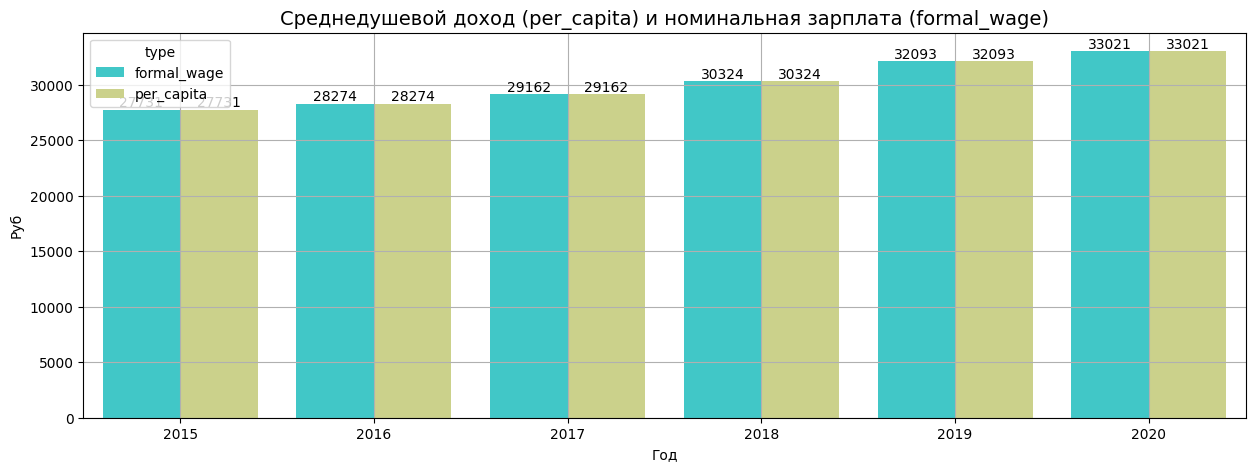

In [86]:
tmp_df = df_cash.loc[ df_cash['type'].isin( ['per_capita','formal_wage'] ), ['type',2015,2016,2017,2018,2019,2020]].groupby( 'type' ).mean().round().astype('int64').stack().reset_index().rename( columns = { "level_1": "Год", 0: "Сумма" } )

plot_bar_df( df = tmp_df, x = 'Год', y = 'Сумма', hue = 'type', figsize = (15,5), hdr = 'Среднедушевой доход (per_capita) и номинальная зарплата (formal_wage)', label_x = 'Год', label_y = 'Руб', print_val = True, legend = True )

Есть рост, но это ничего не говорит (нормировать будем позже). Готовим данные для объединенного датасета

In [87]:
col = 2020
df_cash_model = pd.concat( [
        df_per_capita[col].to_frame().rename( columns = { col: 'per_capita' } ),
        df_formal_wage[col].to_frame().rename( columns = { col: 'formal_wage' } ),
    ],
    axis = 1
).sort_index()
    
df_cash_model

,per_capita,formal_wage
region,,
Алтайский край,23864,23864
Амурская область,35499,35499
Архангельская область,34852,34852
Астраханская область,25199,25199
Белгородская область,32841,32841
...,...,...
Чеченская Республика,24596,24596
Чувашская Республика,21155,21155
Чукотский автономный округ,89541,89541


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [88]:
print_index( df_cash_model )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Смотрим статистику

In [89]:
df_cash_model.describe().round(1)

,per_capita,formal_wage
count,85.0,85.0
mean,33020.5,33020.5
std,14912.5,14912.5
min,16877.0,16877.0
25%,24864.0,24864.0
50%,28596.0,28596.0
75%,33149.0,33149.0
max,89928.0,89928.0


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [90]:
_ = сheck_diff_keys( df_cash_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 9. Распределение малоимущего населения по социально-демографическим группам

- Единицы измерения: процент
- Периодичность сбора (разработки) и временной ряд показателя: Годовая
- Относительная величина, можно сравнивать по регионам
- Источник - Предоставленные данные к проекту

**Методика расчета**
Малоимущее население - население с уровнем денежных доходов ниже границы бедности (до 2020 года включительно – ниже величины прожиточного минимума), определяемого расчетным методом, исходя из фактического состава обследуемого домохозяйства и границы бедности (до 2020 года включительно - величины прожиточного минимума) по социально - демографическим группам населения, установленной в субъекте Российской Федерации по месту проживания обследуемого домохозяйства. Информация представлена по данным Выборочного наблюдения доходов населения и участия в социальных программах. Формирование показателя в соответствии с Методологическими положениями по формированию агрегированных показателей доходов домашних хозяйств на основе программы выборочного наблюдения доходов населения и участия в социальных программах, утвержденными приказом Росстата от 30.09.2025 г. № 544.


In [91]:
################################################################################################
#
# Входные данные:
#    fname - Путь к исходному xls фпайлу
#    to_dict - Приводить названия регионов к словарю (True) или нет (False)
#
# Выходные данные:
#    df - Датафрейм
#
################################################################################################
def preprocess_poverty_socdem( fname, to_dict = True ):
    df = pd.read_excel( fname, header = 2, usecols='A, C, D, E').rename({
        'Unnamed: 0': 'region',
        'Все население': 'all',
        'Дети в возрасте до 16 лет': 'poverty_socdem_16',
        'Население старше трудоспособного возраста': 'poverty_socdem_retired',
        'Население трудоспособного возраста': 'poverty_socdem_work'
    }, axis = 1 )
    
    # Чистим дубликаты
    df = drop_dublicates( df )
    
    # Удаляем данные с пропусками
    df.dropna( thresh = 3, axis = 0, inplace = True )
        
    if to_dict:
        key_drop = [
            '        Архангельская область',
            '        Тюменская область'
        ]
        
        # Приведем к словарю
        df = preprocess_df( df, key_drop = key_drop )
    
    # Извлекаем год из названия файла и сохраняем данные 
    df['year'] = int( to_num( fname ) )
    return df

files = [
    "social_russia_data/poverty_socdem_2017.xls",
    "social_russia_data/poverty_socdem_2018.xls",
    "social_russia_data/poverty_socdem_2019.xls",
    "social_russia_data/poverty_socdem_2020.xls",
]

df = []
df_all = [] # Сохраним "Грязные" данные, чтобы динамику пор РФ глянуть (иначе отсеились бы строки)
for file in files:
    df.append( preprocess_poverty_socdem( file ) )
    df_all.append( preprocess_poverty_socdem( file, to_dict = False ) )
    
df = pd.concat( df ).set_index( 'region' )
df_all = pd.concat( df_all )

df.head()

,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work,year
region,,,,
Белгородская область,43.4,11.8,44.8,2017
Брянская область,42.9,4.9,52.2,2017
Владимирская область,34.8,8.6,56.6,2017
Воронежская область,38.6,5.9,55.6,2017
Ивановская область,33.2,10.9,55.9,2017


Смотрим пропуски

In [92]:
df.isna().sum()


poverty_socdem_16         0
poverty_socdem_retired    0
poverty_socdem_work       0
year                      0
dtype: int64

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 328 entries, Белгородская область to Еврейская автономная область
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   poverty_socdem_16       328 non-null    float64
 1   poverty_socdem_retired  328 non-null    float64
 2   poverty_socdem_work     328 non-null    float64
 3   year                    328 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 12.8+ KB


Смотрим статистику

In [94]:
df.describe().round(1)

,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work,year
count,328.0,328.0,328.0,328.0
mean,38.7,6.2,53.6,2018.4
std,7.2,3.2,8.3,1.1
min,0.0,0.0,0.0,2017.0
25%,35.6,4.2,51.1,2017.0
50%,39.3,5.9,54.2,2018.0
75%,42.8,7.8,57.4,2019.0
max,55.6,18.4,73.6,2020.0


Посмотрим грязные данны по РФ в целом

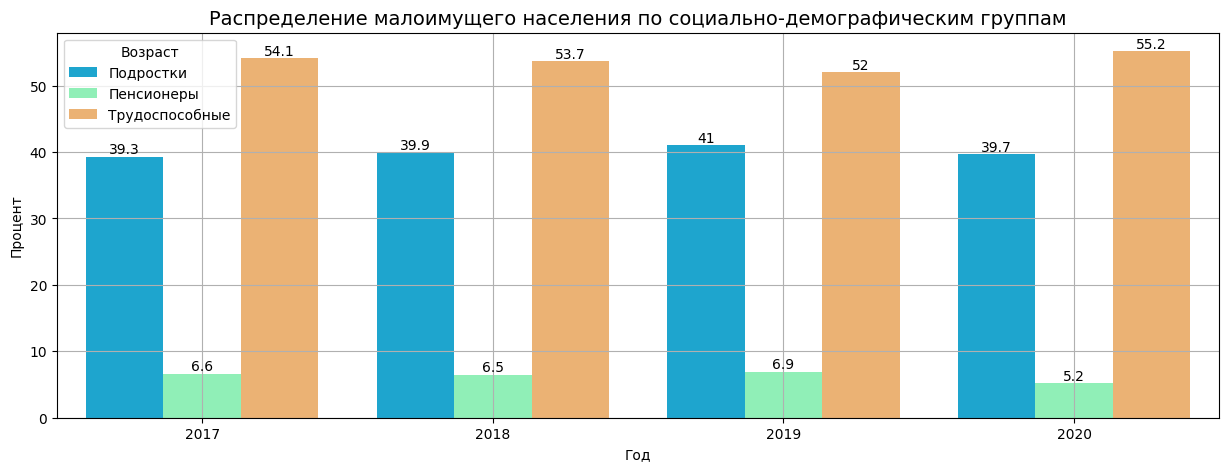

In [95]:
tmp_df = df_all[ df_all['region'] == 'Российская Федерация' ].drop( columns = 'region' ).set_index( 'year' )
tmp_df.columns = ['Подростки', 'Пенсионеры', 'Трудоспособные']
tmp_df = tmp_df.stack().reset_index().rename( columns = { "level_1": "Возраст", 0: "Процент" } )

plot_bar_df( df = tmp_df, x = 'year', y = 'Процент', hue = 'Возраст', figsize = (15,5), hdr = 'Распределение малоимущего населения по социально-демографическим группам', label_x = 'Год', label_y = 'Процент', print_val = True, legend = True )

Динамика не содержит закономерности

Готовим данные по группам населения

In [96]:
# Строки со всеми нулями удалим, как не информативные
df = df[ ~ ((df['poverty_socdem_16'] == 0) | (df['poverty_socdem_retired'] == 0) | (df['poverty_socdem_work'] == 0)) & ((df['poverty_socdem_16'] > 0) | (df['poverty_socdem_retired'] > 0) | (df['poverty_socdem_work'] > 0) )].copy()

df_poverty_socdem_16 = df.pivot_table( index = df.index , columns = 'year', values = 'poverty_socdem_16')
df_poverty_socdem_retired = df.pivot_table( index = df.index , columns = 'year', values = 'poverty_socdem_retired')
df_poverty_socdem_work = df.pivot_table( index = df.index , columns = 'year', values = 'poverty_socdem_work')

cols = ['2017','2018','2019','2020']
df_poverty_socdem_16.columns = cols
df_poverty_socdem_retired.columns = cols
df_poverty_socdem_work.columns = cols

# Проверим на пропуски 
print( f"Пропусков df_poverty_socdem_16: {df_poverty_socdem_16.isna().sum().sum()}, df_poverty_socdem_retired: {df_poverty_socdem_retired.isna().sum().sum()}, df_poverty_socdem_work: {df_poverty_socdem_work.isna().sum().sum()}" )

Пропусков df_poverty_socdem_16: 21, df_poverty_socdem_retired: 21, df_poverty_socdem_work: 21


Причина пропуска - отсутствие данных по регионам за некий год - заполним из ближайшего

In [97]:
df_poverty_socdem_16 = fill_nan_tymeset_df( df_poverty_socdem_16, 2017, 2020 )
df_poverty_socdem_retired = fill_nan_tymeset_df( df_poverty_socdem_retired, 2017, 2020 )
df_poverty_socdem_work = fill_nan_tymeset_df( df_poverty_socdem_work, 2017, 2020 )

print( f"Пропусков df_poverty_socdem_16: {df_poverty_socdem_16.isna().sum().sum()}, df_poverty_socdem_retired: {df_poverty_socdem_retired.isna().sum().sum()}, df_poverty_socdem_work: {df_poverty_socdem_work.isna().sum().sum()}" )

Пропусков df_poverty_socdem_16: 0, df_poverty_socdem_retired: 0, df_poverty_socdem_work: 0


Пропусков нет. Готовим данные для объединенного датасета

In [98]:
col = '2020'
df_poverty_model = pd.concat( [
        df_poverty_socdem_16[col].to_frame().rename( columns = { col: 'poverty_socdem_16' } ),
        df_poverty_socdem_retired[col].to_frame().rename( columns = { col: 'poverty_socdem_retired' } ),
        df_poverty_socdem_work[col].to_frame().rename( columns = { col: 'poverty_socdem_work' } )
    ],
    axis = 1
)

df_poverty_model.describe()

,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work
count,85.000000,85.000000,85.000000
mean,38.720000,5.631765,55.656471
std,6.771277,3.683755,5.993974
min,19.000000,0.300000,42.300000
25%,34.100000,2.900000,51.500000
50%,39.300000,5.000000,54.700000
75%,43.700000,7.000000,59.300000
max,55.600000,18.400000,73.600000


In [99]:
df_poverty_model.head( 3 )

,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work
region,,,
Алтайский край,31.4,9.2,59.4
Амурская область,38.4,4.7,56.9
Архангельская область,28.5,7.2,64.3


Проверим уникальность и количество ключей

In [100]:
print_index( df_poverty_model )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [101]:
_ = сheck_diff_keys( df_poverty_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 10. Жилищные условия по данным 2020 г.
- Относительная величина, можно сравнивать по регионам
- Источник - Предоставленные данные к проекту

In [102]:
fname = 'social_russia_data/housing_2020.xlsx'
df = pd.read_excel( fname, sheet_name = 0, usecols = 'A, C, D, E, F, G, H, I', skipfooter = 0 ).rename( columns = {'Регион': 'region'} )
df.head( 3 )

,region,"в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности","в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность","в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность",затруднились ответить,Размер общей площади в расчете на члена домохозяйства,Размер жилой площади в расчете на члена домохозяйства,Число жилых комнат в расчете на одно домохозяйство
0,Российская Федерация,80.7,15.4,3.8,0.1,24.2,16.9,2.4
1,Центральный федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Белгородская область,86.3,11.7,2.0,0.0,25.1,17.8,2.6


In [103]:
df.columns = ['region','housing_Нет_стесненности', 'housing_Не_большая_стесненность', 'housing_Большая_стесненность', 'housing_Не_известен', 'housing_Общая_площадь', 'housing_Жилая_площадь', 'housing_Комнат']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   region                           94 non-null     object 
 1   housing_Нет_стесненности         86 non-null     float64
 2   housing_Не_большая_стесненность  86 non-null     float64
 3   housing_Большая_стесненность     86 non-null     float64
 4   housing_Не_известен              86 non-null     float64
 5   housing_Общая_площадь            86 non-null     float64
 6   housing_Жилая_площадь            86 non-null     float64
 7   housing_Комнат                   86 non-null     float64
dtypes: float64(7), object(1)
memory usage: 6.0+ KB


Предобработка

In [104]:
# # Приведем к словарю
df = drop_dublicates( df )
   
# Исправляем ошибки ввода
for col in df.columns[1:].to_list():
    df[col] = df[col].apply( lambda s: to_num( s ) )    

# Приводим территории к словарю
df = preprocess_df( df, key_drop = None ).set_index( 'region' ).sort_index()

df.head( 3 )

,housing_Нет_стесненности,housing_Не_большая_стесненность,housing_Большая_стесненность,housing_Не_известен,housing_Общая_площадь,housing_Жилая_площадь,housing_Комнат
region,,,,,,,
Алтайский край,83.2,13.4,3.3,0.1,25.9,18.0,2.4
Амурская область,77.3,16.8,5.9,0.0,23.2,17.3,2.3
Архангельская область,83.3,14.5,2.2,0.0,24.6,16.9,2.4


Смотрим пропуски

In [105]:
df[df.isna().mean( axis = 1 ) > 0]

,housing_Нет_стесненности,housing_Не_большая_стесненность,housing_Большая_стесненность,housing_Не_известен,housing_Общая_площадь,housing_Жилая_площадь,housing_Комнат
region,,,,,,,


Оставим признаки

In [106]:
df = df[[ 'housing_Нет_стесненности', 'housing_Жилая_площадь', 'housing_Комнат' ]]
df.head()

,housing_Нет_стесненности,housing_Жилая_площадь,housing_Комнат
region,,,
Алтайский край,83.2,18.0,2.4
Амурская область,77.3,17.3,2.3
Архангельская область,83.3,16.9,2.4
Астраханская область,77.5,19.2,2.3
Белгородская область,86.3,17.8,2.6


Смотрим статистику

In [107]:
df.describe().round(1)

,housing_Нет_стесненности,housing_Жилая_площадь,housing_Комнат
count,85.0,85.0,85.0
mean,81.0,17.2,2.5
std,5.0,2.3,0.5
min,67.2,13.6,1.7
25%,78.6,15.8,2.2
50%,81.0,16.9,2.4
75%,84.0,18.1,2.5
max,94.7,27.8,4.9


Проверим уникальность и количество ключей

In [108]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Готовим данные для объединенного датасета

In [109]:
df_housing_model = df.copy()

Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [110]:
_ = сheck_diff_keys( df_housing_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 11. Валовой региональный продукт на душу населения
- Единицы измерения: рубль
- Периодичность сбора (разработки) и временной ряд показателя: Годовая
- Особенность: относительная величина, но сравнивать по регионам нельзя - разный прожиточный минимум. Нужно нормировать
- Источник - Предоставленные данные к проекту

**Методика расчета**
Объем валового регионального продукта на душу населениярассчитывается как отношение валового регионального продукта в текущих основных ценах к среднегодовой численности постоянного населения.

In [111]:
fname = 'social_russia_data/gross_regional_product_1996_2020.xls'
df = pd.read_excel(fname, usecols = 'A, U:Z', skiprows = 2).rename( columns = {'Unnamed: 0': 'region'} )
df.head( 3 )

,region,2015,2016,2017,2018,2019,2020
0,Российская Федерация,449097.9,505337.7,543065.9,614333.2,646144.1,640519.0
1,Центральный федеральный округ,580706.6,663881.8,711031.6,792780.9,835858.8,854978.5
2,Белгородская область,447619.7,501467.8,539720.5,588641.5,617426.5,646569.0


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  101 non-null    object 
 1   2015    96 non-null     float64
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


Посмотрим по "грязным" данным динамику в целом по РФ

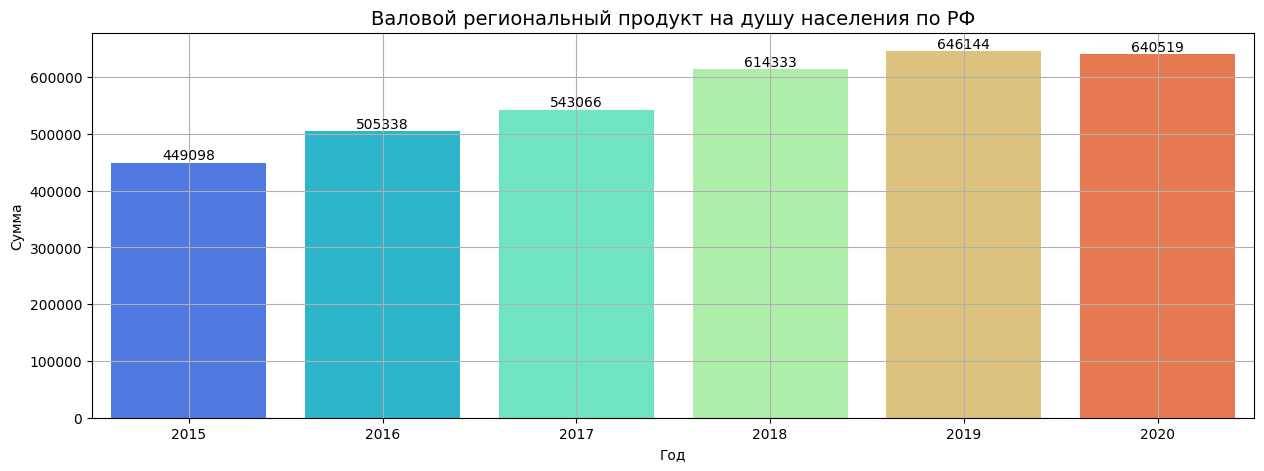

In [113]:
tmp_df = df[ df['region'] == 'Российская Федерация' ].drop( columns = 'region', axis = 1 ).stack().reset_index().rename( columns = { "level_1": "Год", 0: "Сумма" } )

plot_bar_df( df = tmp_df, x = 'Год', y = 'Сумма', hue = None, figsize = (15,5), hdr = 'Валовой региональный продукт на душу населения по РФ', label_x = 'Год', label_y = 'Сумма', print_val = True, legend = True )

В целом показатель растет. Предобработка данных

In [114]:
# Удалим дубликаты
df = drop_dublicates( df ) 

# Список для удалений строк 
key_drop = [
    '        Архангельская область', 
    '        Тюменская область', 
]   

# Приведем территории к словарю
df = preprocess_df( df, key_drop = key_drop, rows_drop_if_all_cols_null = None ).set_index( 'region' ).sort_index()

df.head( 3 )

,2015,2016,2017,2018,2019,2020
region,,,,,,
Алтайский край,204933.1,224525.8,231268.4,247599.3,271319.7,291156.9
Амурская область,343385.7,370192.4,373935.1,419905.2,521060.1,571362.1
Архангельская область,352837.9,400764.6,441961.6,493205.1,509917.0,514200.4


In [115]:
df[ df.isna().sum( axis = 1 ) > 0 ]

,2015,2016,2017,2018,2019,2020
region,,,,,,


Пропусков нет. Проверим уникальность и количество ключей

In [116]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Готовим данные для объединенного датасета

In [117]:
col = '2020'
df_gross_regional_product_model = df[col].to_frame().rename( columns = { col: 'gross_regional_product' } )

Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [118]:
_ = сheck_diff_keys( df_gross_regional_product_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 12. Алкоголизм, наркомания
- Единица измерения - количество акогольных/наркотических психозов на 100 тыс. населения.
- Источник - Предоставленные данные к проекту

In [119]:
fname = 'social_russia_data/drug_alco.xlsx'

df_alco = pd.read_excel( fname, 1 )
df_drug = pd.read_excel( fname, 3 )

display( 'Алкоголизм' )
df_alco.info()
display( 'Наркомания' )
df_drug.info()

'Алкоголизм'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  95 non-null     object
 1   2017    95 non-null     object
 2   2018    95 non-null     object
dtypes: object(3)
memory usage: 2.4+ KB


'Наркомания'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  95 non-null     object
 1   2017    95 non-null     object
 2   2018    95 non-null     object
dtypes: object(3)
memory usage: 2.4+ KB


Предобработка

In [120]:
################################################################################################
#
# preprocess_drug_alco - Первичная предобработка датасета. 
#
# Входные данные:
#    df - Первичный (глязный) датасет
# 
# Выходные данные:
#    df - Обработанный датасет
#
################################################################################################
def preprocess_drug_alco( df ):
    # Приведем к словарю
    key_drop = [
        "Главное медицинское управление Управления делами Президента Российской Федерации"
    ]
    df = preprocess_df( df, key_drop = key_drop )

    # изменим тип столбцов на float
    cols = ['region']
    for column in df.columns.to_list()[1:]:
        df[column] = df[column].astype( float )
        
        # Приведем название колокон к строке
        cols.append( str( column ) ) 
    
    df.columns = cols
    return df

In [121]:
display( df_alco.head(3) )
display( df_drug.head(3) )

,region,2017,2018
0,Российская Федерация,53.2,51.6
1,Центральный федеральный округ,46.2,44.9
2,Белгородская область,45.2,41.3


,region,2017,2018
0,Российская Федерация,11,10.1
1,Центральный федеральный округ,10.3,9.2
2,Белгородская область,2.3,3.2


Приведем территории к словарю и склеим данные 

In [122]:

df_alco = preprocess_drug_alco( df_alco ).set_index( 'region' )
df_drug = preprocess_drug_alco( df_drug ).set_index( 'region' )

df_alco.shape, df_drug.shape

((85, 2), (85, 2))

Проверим и заполним пропуски ближайшии датами

In [123]:
display( df_alco[df_alco.isna().sum( axis = 1 ) > 0] )
display( df_drug[df_drug.isna().sum( axis = 1 ) > 0] )

,2017,2018
region,,


,2017,2018
region,,


Смотрим уникальность и количество ключей

In [124]:
print_index( df_alco )

Топ 3 повторов ключей:
----------------------
region
Белгородская область               1
Пензенская область                 1
Ямало-Ненецкий автономный округ    1
Name: count, dtype: int64

Количество ключей: 85


In [125]:
print_index( df_drug )

Топ 3 повторов ключей:
----------------------
region
Белгородская область               1
Пензенская область                 1
Ямало-Ненецкий автономный округ    1
Name: count, dtype: int64

Количество ключей: 85


Готовим данные для объединенного датасета

In [126]:
col = '2018'
df_alco_drug_model = pd.concat( [
        df_alco[ col ].to_frame().rename( columns = { col: 'alco' } ), 
        df_drug[ col ].to_frame().rename( columns = { col: 'drug' } ),
    ], 
    axis = 1 
).sort_index()
df_alco_drug_model.head( 3 )

,alco,drug
region,,
Алтайский край,88.1,17.4
Амурская область,113.3,24.4
Архангельская область,64.7,9.2


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [127]:
_ = сheck_diff_keys( df_alco_drug_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 13. Рождаемость — рождённые в этом месяце, по регионам, без учёта мертворождённых.
- Единица измерения: количество человек за месяц
- Особенность: Абсолютная величина за месяц, сравнивать по регионам нельзя
- Для модели нужно привести к годовой относительной величине
- Источник - Предоставленные данные к проекту

In [128]:
fname = 'social_russia_data/newborn_2006_2022_monthly.csv'
df = pd.read_csv(  fname, sep = ';', decimal = ',', na_values=np.nan).drop( columns = ['Unnamed: 198'], axis = 1 ).rename( columns = { 'Region': 'region' } )
df.head( 3 )

,region,январь 2006 г.,февраль 2006 г.,март 2006 г.,апрель 2006 г.,май 2006 г.,июнь 2006 г.,июль 2006 г.,август 2006 г.,сентябрь 2006 г.,...,август 2021 г.,сентябрь 2021 г.,октябрь 2021 г.,ноябрь 2021 г.,декабрь 2021 г.,январь 2022 г.,февраль 2022 г.,март 2022 г.,апрель 2022 г.,май 2022 г.
0,Российская Федерация,109422.00,114068.99,129177.99,113391.99,125099.99,124238.0,125926.99,140227.99,123949.99,...,125356.99,121645.99,120080.99,114976.99,117945.99,103782.0,101082.0,115512.0,99696.99,103159.0
1,Центральный федеральный округ,24998.99,25539.99,29558.99,25781.00,29137.00,28837.0,28997.99,31590.99,27755.99,...,31329.99,29727.00,29532.99,29093.00,29477.00,25827.0,25678.0,28086.0,24979.99,26304.0
2,Белгородская область,1040.00,1094.00,1190.00,1044.00,1228.00,1249.0,1224.00,1389.00,1157.00,...,1154.00,1084.00,1053.00,990.00,1028.00,861.0,941.0,956.0,801.00,869.0


Предобработка

In [129]:
# Чистим дубликаты
df = drop_dublicates( df ).set_index( 'region' )

# Учтем особенности статистики по этим регионам
df.loc[ 'Архангельская область (кроме Ненецкого автономного округа)'] = \
    (
        df.loc[ 'Архангельская область']\
        - df.loc[ 'Ненецкий автономный округ (Архангельская область)']\
    )

df.loc[ 'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)'] =\
    (
        df.loc[ 'Тюменская область']
        - df.loc[ 'Ханты-Мансийский автономный округ - Югра (Тюменская область)']
        - df.loc[ 'Ямало-Ненецкий автономный округ (Тюменская область)']
    )

# Суммируем данные за год
cols_old = df.columns.to_list()
years = list( range( 2006, 2021 ) )

for year in years:
    # Подготавливаем список данных по месяцам
    month = None
    cols = []
    for col in cols_old:
        if str( year ) in col:
            cols.append( col )
            
    # И суммируем данные за год
    df[ year ] = df[cols].sum( axis = 1 )

# Удаляем первичные колонки с месяцем
df.drop( columns = cols_old, inplace = True )

key_drop = [
    "Архангельская область",
    "Тюменская область",
]

df.reset_index( inplace = True )

# Приведем к словарю
df = preprocess_df( df, key_drop = key_drop, rows_drop_if_all_cols_null = years ).set_index( 'region' ).sort_index()

# Приведем к целым значениям
df = df[years].round().astype( 'int64' ).copy()

# Удалим лишние ключи-регионы
df = df[ df.index.isin( df_population_model.index ) ].copy()

# Стандартизируем название колонок
df.columns = [ str(x) for x in list( range( 2006, 2021 ) ) ]

df.shape

(85, 15)

Статистика

In [130]:
df.describe()

,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.00000,85.000000,85.000000,85.000000,85.000000
mean,17367.305882,18851.611765,20205.658824,20754.870588,21054.388235,21103.858824,22308.976471,22366.847059,22565.764706,22872.188235,22273.60000,19880.988235,18877.517647,17464.905882,16891.176471
std,15353.075164,16578.321617,18001.943782,18901.956941,19654.355869,19955.733667,21336.227710,21635.592049,22155.531124,22455.642719,22555.02613,20579.950033,19919.396016,19295.646753,18355.295583
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,683.000000,671.00000,658.000000,608.000000,526.000000,537.000000
25%,7478.000000,8284.000000,8628.000000,8950.000000,8831.000000,9066.000000,9225.000000,9201.000000,9164.000000,9099.000000,8566.00000,8000.000000,7438.000000,6835.000000,6642.000000
50%,12380.000000,13370.000000,14200.000000,14406.000000,14355.000000,14253.000000,15144.000000,15042.000000,15033.000000,15025.000000,14605.00000,12797.000000,11998.000000,11005.000000,10584.000000
75%,23717.000000,26130.000000,27492.000000,28194.000000,28697.000000,28055.000000,29736.000000,29844.000000,29577.000000,28739.000000,27307.00000,23616.000000,22466.000000,20821.000000,19663.000000
max,94055.000000,100771.000000,107779.000000,115786.000000,123142.000000,126655.000000,134653.000000,136021.000000,137583.000000,142390.000000,145252.00000,133889.000000,132970.000000,136357.000000,123524.000000


Заменим 0 на пропуски и заполним из ближайшего года

In [131]:
# Заменим 0 на пропуски
for col in df.columns:
    df.loc[ df[ col ] == 0 , col] = np.nan

# И заполним ближайшим значением
df = fill_nan_tymeset_df( df = df, syear = 2006, eyear = 2020, direction = False )

Посмотрим динамику в целом

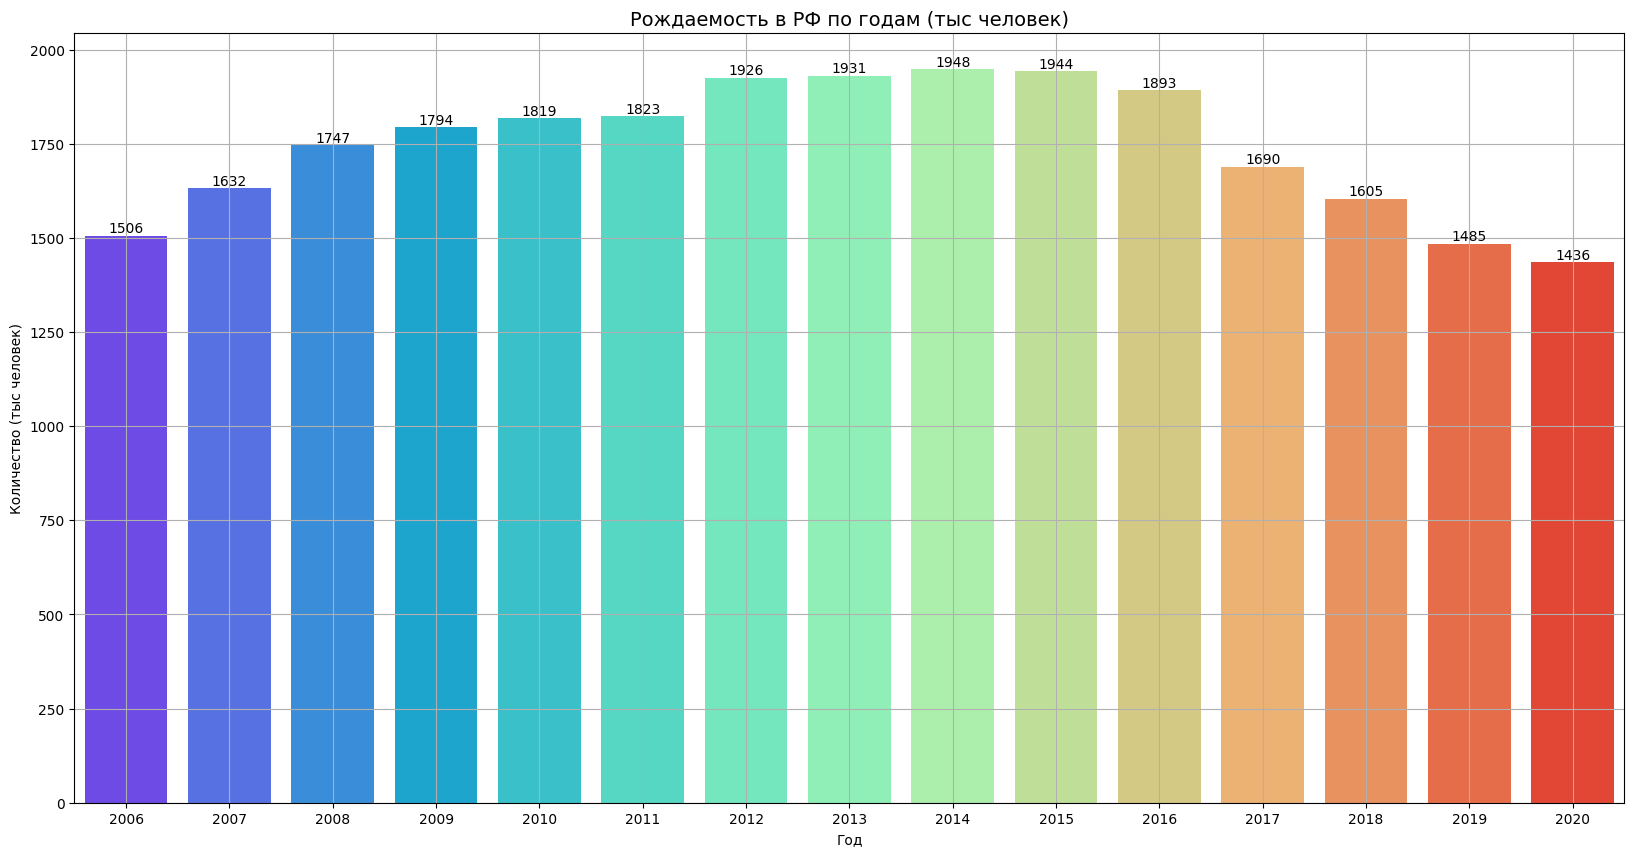

In [132]:
tmp_df = (df.sum() / 1000).round().to_frame().rename( columns = { 0: "Количество" } )

plot_bar_df( df = tmp_df, x = tmp_df.index, y = 'Количество', hue = None, figsize = (20,10), hdr = 'Рождаемость в РФ по годам (тыс человек)', label_x = 'Год', label_y = 'Количество (тыс человек)', print_val = True, legend = False )

Пик рождаемости был в 2012-2015 годах (с прибавлением 2х регионов), но в целом показатель снижается

Смотрим количество и уникальность ключей

In [133]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Готовим данные для объединенного датасета bp 2020г

In [134]:
df_newborn = df.copy()

col = '2020'
df_newborn_model = df_newborn[ col ].to_frame().rename( columns = { col: "newborn" } )

df_newborn_model.head(3)

,newborn
region,
Алтайский край,19976.0
Амурская область,7853.0
Архангельская область,8906.0


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [135]:
df_newborn_model.describe()

,newborn
count,85.000000
mean,16891.176471
std,18355.295583
min,537.000000
25%,6642.000000
50%,10584.000000
75%,19663.000000
max,123524.000000


Сверим различие ключей

In [136]:
_ = сheck_diff_keys( df_newborn_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 14. Объём отгруженных товаров собственного производства или работ/услуг, выполненных собственными силами, по видам деятельности за 2005–2016 гг., 2017–2020 гг. (в тысячах рублей, значение показателя за год, полный круг).
**regional_production_\*_\*.csv** 

- Единица измерения: рубль
- Периодичность: год
- Особенность: абсолютная величина, нельзя сравнивать по регионам. Для модели приведем к относительной величины
- Источник - Предоставленные данные к проекту

Используем данные за 2017-2020 годы

In [137]:
fname = 'social_russia_data/regional_production_2017_2020.csv'
df = pd.read_csv( fname )
display( df.head( 3 ) )

,region,production_field,2017,2018,2019,2020
0,Российская Федерация,ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ,1.391616e+10,1.819387e+10,1.832413e+10,1.449890e+10
1,Российская Федерация,Добыча угля,1.228407e+09,1.567151e+09,1.392654e+09,1.100662e+09
2,Российская Федерация,Добыча и обогащение угля и антрацита,1.151523e+09,1.472893e+09,1.302804e+09,1.012754e+09


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            604 non-null    object 
 1   production_field  604 non-null    object 
 2   2017              604 non-null    float64
 3   2018              604 non-null    float64
 4   2019              604 non-null    float64
 5   2020              604 non-null    float64
dtypes: float64(4), object(2)
memory usage: 28.4+ KB


Смотрим пропуски

In [139]:
df.isna().sum().sum()

np.int64(0)

Их нет. Предобработка

In [140]:
# Список для удалений строк 
key_drop = [
    '        Архангельская область', 
    '        Тюменская область', 
]    

df.drop( columns = ['production_field'], inplace = True )

# Приведем территории к справочнику
df = preprocess_df( df = df, key_drop = key_drop, rows_drop_if_all_cols_null = ['2017','2018','2019','2020'] )

df_prod = df.copy()
df = df.groupby( 'region' ).sum()
df.shape

(85, 4)

Посмотрим динамику по годам

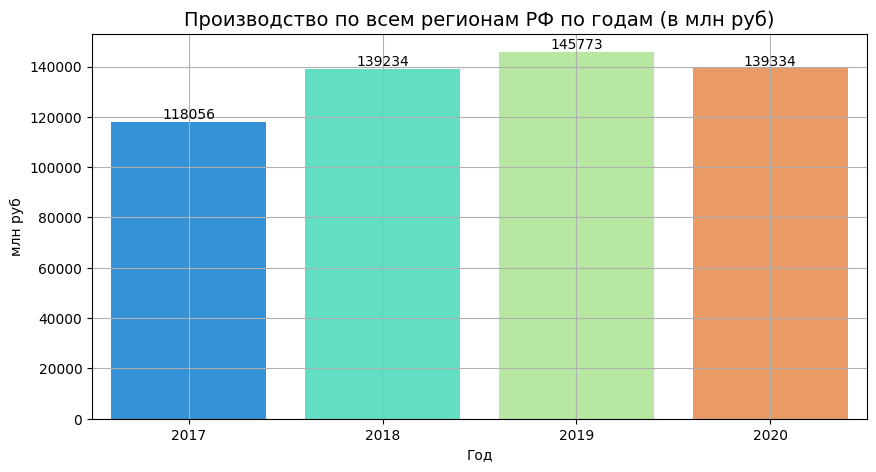

In [141]:
tmp_df = (df.sum() / 1000000).round().to_frame().rename( columns = {0: "Год"} )

plot_bar_df( df = tmp_df, x = tmp_df.index, y = 'Год', hue = None, figsize = (10,5), hdr = 'Производство по всем регионам РФ по годам (в млн руб)', label_x = 'Год', label_y = 'млн руб', print_val = True, legend = False )

Тенденция не понятна

In [142]:
df.head()

,2017,2018,2019,2020
region,,,,
Алтайский край,7.359764e+08,7.711927e+08,8.383179e+08,8.524434e+08
Амурская область,2.688441e+08,2.687608e+08,3.400267e+08,4.045765e+08
Архангельская область,7.090098e+08,6.064711e+08,5.335849e+08,6.641070e+08
Астраханская область,6.265697e+08,8.837665e+08,9.015147e+08,7.245978e+08
Белгородская область,1.566651e+09,1.790868e+09,1.878073e+09,1.948294e+09


Готовим данные для объединенного датасета

In [143]:
df_production = df.copy()

col = '2020'
df_production_model = df_production.loc[:, [col]].rename( columns = { col: 'regional_production' } )

df_production_model.head( 3 )

,regional_production
region,
Алтайский край,8.524434e+08
Амурская область,4.045765e+08
Архангельская область,6.641070e+08


Проверим уникальность и количество индексов

In [144]:
print_index( df_production_model )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Смотрим статистику

In [145]:
df_production_model.describe()

,regional_production
count,8.500000e+01
mean,1.639223e+09
std,2.531307e+09
min,8.555011e+06
25%,4.045765e+08
50%,7.842928e+08
75%,1.868711e+09
max,1.956241e+10


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [146]:
_ = сheck_diff_keys( df_production_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 15. Сведения о преступлениях, совершённых отдельными категориями лиц за 2016–2022 гг., по месяцам, регионам, категориям лиц, категориям преступлений.
- Источник - Предоставленные данные к проекту

In [147]:
# Cоздадим функцию обработки датасета из папки crimes
def preprocess_crimes( fname, year ):
    df = pd.read_excel( fname, usecols='B:D,F:L', skiprows = 11, sheet_name = 'Строка 1' )
    df.columns = ['region', f'crim_before_17', f'crim_old', f'crim_group1', f'crim_group2', f'crim_group3', f'crim_group4', f'crim_alco', f'crim_nark', f'crim_tox']
    df['year'] = year
    df = drop_dublicates( df )
    
    df['crim_group'] = df['crim_group1'] + df['crim_group2'] + df['crim_group3'] + df['crim_group4']
    df['crim_alco_nark_tox'] = df['crim_alco'] + df['crim_nark'] + df['crim_tox']
    return df[['region', 'year', 'crim_alco_nark_tox', 'crim_group']]


# Читаем данные и делаем первичную выборку признаков
tmp_df = []
for year in range( 2016,2021 ):
    y = str( year )
    tmp_df.append( preprocess_crimes( f"social_russia_data/crimes/4-EGS_Razdel_4_12{y}.xls", y ) )

df = pd.concat( tmp_df, axis = 0 )
df.head(3)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (122053) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (122053) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


,region,year,crim_alco_nark_tox,crim_group
0,Российская Федерация,2016,468591,104366
1,Центральный федеральный округ,2016,78555,25147
2,Белгородская область,2016,2716,767


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515 entries, 0 to 102
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   region              515 non-null    object
 1   year                515 non-null    object
 2   crim_alco_nark_tox  515 non-null    int64 
 3   crim_group          515 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 20.1+ KB


Смотрим пропуски

In [149]:
df.isna().sum()

region                0
year                  0
crim_alco_nark_tox    0
crim_group            0
dtype: int64

Их нет. Предобработка

In [150]:
key_drop = [
    'Транспорт России'
]

df_crim = preprocess_df( df = df, key_drop = key_drop ).set_index( 'region' ).sort_index()
df_crim.head()

,year,crim_alco_nark_tox,crim_group
region,,,
Алтайский край,2019,9927,1298
Алтайский край,2018,10966,1479
Алтайский край,2016,14116,1643
Алтайский край,2017,12322,1545
Алтайский край,2020,9442,1054


Готовим данные для объединенного датасета

In [151]:
df_crim_model = df_crim[ df_crim['year'] == '2020' ].drop( columns = 'year' )
df_crim_model.head( 3 )

,crim_alco_nark_tox,crim_group
region,,
Алтайский край,9442,1054
Амурская область,3233,518
Архангельская область,4046,1066


Смотрим статистику

In [152]:
df_crim_model.describe()

,crim_alco_nark_tox,crim_group
count,85.000000,85.000000
mean,3778.905882,1051.941176
std,2890.241857,1191.074928
min,125.000000,14.000000
25%,1851.000000,453.000000
50%,2959.000000,751.000000
75%,5241.000000,1172.000000
max,11888.000000,8943.000000


Смотрим уникальность и количество ключей

In [153]:
print_index( df_crim_model )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [154]:
_ = сheck_diff_keys( df_crim_model, df_population_model )

Разница в регонах: 0 шт, set()


### 16. Оборот розничной торговли на душу населения, в рублях.
- Единицы измерения: рубль
- Периодичность: год
- Особенность: Относительная величина
- Источник - Предоставленные данные к проекту

Требуется нормализация данныхз по прожиточному минимуму

In [155]:
fname = 'social_russia_data/retail_turnover_per_capita_2000_2021.xls'
df = pd.read_excel( fname, skiprows = 2, usecols = 'A,R:W' ).rename( columns = { 'Unnamed: 0': 'region'} )
df.head()

,region,2015,2016,2017,2018,2019,2020
0,NaN,значение показателя за год,значение показателя за год,значение показателя за год,значение показателя за год,значение показателя за год,значение показателя за год
1,Российская Федерация,188017,192541,202568,215074,229104,231283
2,Центральный федеральный округ,237737,243426,258278,277011,296368,301192
3,Белгородская область,178097,192504,203298,217059,230704,237076
4,Брянская область,177048,179767,192775,209987,225818,225643


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  108 non-null    object
 1   2015    101 non-null    object
 2   2016    100 non-null    object
 3   2017    99 non-null     object
 4   2018    97 non-null     object
 5   2019    97 non-null     object
 6   2020    97 non-null     object
dtypes: object(7)
memory usage: 6.1+ KB


Смотрим динамику "грязных" данных

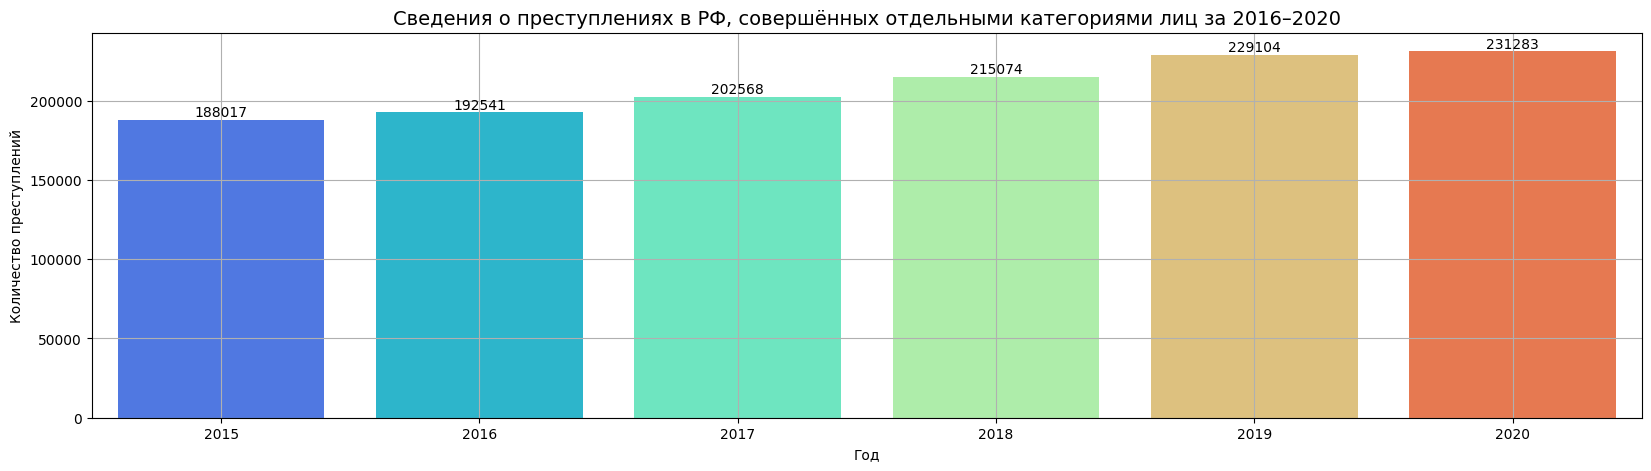

In [157]:
tmp_df = df[df['region'] == 'Российская Федерация'].drop( columns = 'region' ).stack().reset_index().rename( columns = { "level_1": "Год", 0: "Оборот" } )

plot_bar_df( df = tmp_df, x = 'Год', y = 'Оборот', hue = None, figsize = (20,5), hdr = 'Сведения о преступлениях в РФ, совершённых отдельными категориями лиц за 2016–2020', label_x = 'Год', label_y = 'Количество преступлений', print_val = True, legend = False )

Показатель растет, т.к. численность населения в целом падает, нормализованное значение показателя растет.

Предобработка данных

In [158]:
# Удаляем дубли и делаем индекс
df = drop_dublicates( df )

# Приводим ключи к словарю
key_drop = [
    '        Архангельская область',
    '        Тюменская область',
    '            Архангельская область (без АО)',
    '            Тюменская область (без АО)'
    
]

cols = ['2015','2016','2017','2018','2019','2020']

# Приводим к словарю и удалим строки с пропусками во всех полях интересующих нас годов
df = preprocess_df( df, key_drop = key_drop, rows_drop_if_all_cols_null = cols ).set_index( 'region' )

# Столбцы в символьном виде - преобразуем к числовому
for column in cols:
    df[column] = df[column].astype( float )

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Белгородская область to Чукотский автономный округ
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   2015    85 non-null     float64
 1   2016    85 non-null     float64
 2   2017    85 non-null     float64
 3   2018    85 non-null     float64
 4   2019    85 non-null     float64
 5   2020    85 non-null     float64
dtypes: float64(6)
memory usage: 4.6+ KB


In [159]:
df.head( 3 )

,2015,2016,2017,2018,2019,2020
region,,,,,,
Белгородская область,178097.0,192504.0,203298.0,217059.0,230704.0,237076.0
Брянская область,177048.0,179767.0,192775.0,209987.0,225818.0,225643.0
Владимирская область,139408.0,143643.0,153088.0,164519.0,175251.0,177680.0


Смотрим пропуски

In [160]:
df[ df[cols].isna().mean( axis = 1 ) > 0 ]

,2015,2016,2017,2018,2019,2020
region,,,,,,


Пропусков нет. Делам целочисленными

In [161]:
df = df.astype( 'int64' )

Смотрим уникальность и количество ключей

In [162]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Белгородская область    1
Пензенская область      1
Тюменская область       1
Name: count, dtype: int64

Количество ключей: 85


Смотрим статистику

In [163]:
df.describe().round()

,2015,2016,2017,2018,2019,2020
count,85.0,85.0,85.0,85.0,85.0,85.0
mean,160795.0,165684.0,174238.0,184832.0,196911.0,199342.0
std,46585.0,46870.0,49570.0,52563.0,55465.0,56439.0
min,46598.0,45965.0,46464.0,51027.0,51702.0,50713.0
25%,134072.0,137844.0,145186.0,153012.0,161544.0,164879.0
50%,161161.0,162400.0,170837.0,180022.0,192070.0,197028.0
75%,186603.0,195514.0,205496.0,217059.0,231113.0,232860.0
max,351448.0,346602.0,363391.0,382016.0,403426.0,408674.0


Готовим данные для объединенного датасета

In [164]:
col = '2020'
df_retail_model = df[ col ].to_frame().rename( columns = { col: "retail" } )
df_retail_model.head( 3 )

,retail
region,
Белгородская область,237076
Брянская область,225643
Владимирская область,177680


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [165]:
_ = сheck_diff_keys( df_retail_model, df_population_model )

Разница в регонах: 0 шт, set()


### 17. Количество детей

Данные портала https://tochno.st за 2020 г.

In [166]:
fname = 'social_russia_data/child_count_2020.xlsx'
df = pd.read_excel( fname, skiprows = 1, usecols = 'B,C').rename( columns = { 'Регион': 'region', "Всего детей в регионе, человек": "child_count"} )
df.head()

,region,child_count
0,Еврейская автономная область,36731
1,Забайкальский край,267219
2,Камчатский край,65590
3,Магаданская область,29431
4,Приморский край,376589


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   region       85 non-null     object
 1   child_count  85 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ KB


Смотрим пропуски

In [168]:
df.isna().sum().sum()

np.int64(0)

Их нет. Предобработка

In [169]:
# Удаляем дубли и делаем индекс
df = drop_dublicates( df )

# Приводим ключи к словарю
key_drop = [
    '        Архангельская область',
    '        Тюменская область',
    '            Архангельская область (без АО)',
    '            Тюменская область (без АО)'
    
]

cols = ['child_count']

# Приводим к словарю и удалим строки с пропусками во всех полях интересующих нас годов
df = preprocess_df( df, key_drop = key_drop, rows_drop_if_all_cols_null = cols).set_index( 'region' )

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Еврейская автономная область to Чеченская Республика
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   child_count  85 non-null     int64
dtypes: int64(1)
memory usage: 1.3+ KB


Готовим данные для объединенного датасета

In [170]:
df_child_count_model = df.copy()
df_child_count_model.head( 3 )

,child_count
region,
Еврейская автономная область,36731
Забайкальский край,267219
Камчатский край,65590


Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [171]:
_ = сheck_diff_keys( df_child_count_model, df_population_model )

Разница в регонах: 0 шт, set()


### 18. Количество пенсионеров
- Единица измеренния: тыс. человек

https://www.fedstat.ru/indicator/31554 - retired_count_2016_2021.xls

In [172]:
fname = 'social_russia_data/retired_count_2016_2021.xls'
df = pd.read_excel( fname, skiprows = 3, usecols = 'A:G' )
df.columns = [ 'region', '2016', '2017', '2018', '2019', '2020', '2021' ]
df.head()

,region,2016,2017,2018,2019,2020,2021
0,Российская Федерация,42729.0,43177.0,43504.0,43865.0,43546.0,42977.0
1,Центральный федеральный округ,11314.0,11426.0,11525.0,11620.0,11543.0,11393.0
2,Белгородская область,505.0,510.0,513.0,516.0,512.0,506.0
3,Брянская область,415.0,417.0,418.0,419.0,416.0,411.0
4,Владимирская область,460.0,461.0,462.0,462.0,456.0,447.0


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  100 non-null    object 
 1   2016    97 non-null     float64
 2   2017    96 non-null     float64
 3   2018    96 non-null     float64
 4   2019    96 non-null     float64
 5   2020    96 non-null     float64
 6   2021    96 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


Предобработка

In [174]:
df = drop_dublicates( df )

# Приведем к словарю
key_drop = [
    '        Архангельская область', 
    '        Тюменская область', 
    ]   

df = preprocess_df( df = df, key_drop = key_drop, rows_drop_if_all_cols_null = None ).set_index( 'region' ).sort_index( ascending = True ).astype( 'int64' )

# Учтем размерность - тысячи человек
df = df * 1000

df.head(3)

,2016,2017,2018,2019,2020,2021
region,,,,,,
Алтайский край,750000,758000,762000,766000,758000,743000
Амурская область,235000,235000,234000,235000,231000,226000
Архангельская область,415000,415000,413000,411000,407000,401000


Провкерим пропуски

In [175]:
df.isna().sum().sum()

np.int64(0)

Их нет. Проверим уникальность и количество ключей

In [176]:
print_index( df )

Топ 3 повторов ключей:
----------------------
region
Алтайский край         1
Республика Мордовия    1
Самарская область      1
Name: count, dtype: int64

Количество ключей: 85


Смотрим статистику

In [177]:
df.describe().round()

,2016,2017,2018,2019,2020,2021
count,85.0,85.0,85.0,85.0,85.0,85.0
mean,502682.0,507965.0,511800.0,516059.0,512306.0,505612.0
std,461006.0,468649.0,475357.0,482208.0,480857.0,475901.0
min,14000.0,14000.0,14000.0,14000.0,14000.0,14000.0
25%,235000.0,235000.0,234000.0,235000.0,231000.0,226000.0
50%,386000.0,387000.0,388000.0,390000.0,386000.0,380000.0
75%,624000.0,646000.0,670000.0,682000.0,677000.0,676000.0
max,2931000.0,2993000.0,3049000.0,3102000.0,3100000.0,3071000.0


Готовим данные для объединенного датасета

In [178]:
df_retired_count = df.copy()

col = '2020'
df_retired_count_model = df[ col ].to_frame().rename( columns = { col: "retired_count" } )

Сверим расхождения ключей (регионов) с нормирующим датасетом (должно быть 0)

In [179]:
_ = сheck_diff_keys( df_retired_count_model, df_population_model_norm )

Разница в регонах: 0 шт, set()


### 19. Геолокация

- Источник данных - web-сервис


In [180]:
fname = 'social_russia_data/regions_geo.csv'
df = pd.read_csv( fname )
df.head( 3 )

,region,lat,lon
0,Алтайский край,53.3468,83.7768
1,Амурская область,50.2839,127.5414
2,Архангельская область,64.5401,40.5433


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  85 non-null     object 
 1   lat     85 non-null     float64
 2   lon     85 non-null     float64
dtypes: float64(2), object(1)
memory usage: 2.1+ KB


In [182]:
df.isna().sum().sum()

np.int64(0)

Пропусков нет

In [183]:
df.shape

(85, 3)

In [184]:
# Приводим к словарю и удалим строки с пропусками во всех полях интересующих нас годов
df = preprocess_df( df = df, key_drop = None, rows_drop_if_all_cols_null = None ).set_index( 'region' ).sort_index( ascending = True )

In [185]:
_ = сheck_diff_keys( df, df_population_model_norm )

Разница в регонах: 0 шт, set()


In [186]:
df_regions_geo = df.copy()

### Объединяем датафреймы (2015-2020 годы)

In [187]:
# объединим все данные в один датасет
df_all = pd.concat( [
    df_population_model_norm,
    df_child_mortality_model, 
    df_cost_of_living_model_norm,
    df_disabled_model,
    df_morbidity_model,
    df_poverty_model,
    df_poverty_percent_model,
    df_welfare_model,
    df_cash_model,
    df_housing_model,
    df_gross_regional_product_model, 
    df_alco_drug_model,
    df_newborn_model,
    df_crim_model,
    df_retail_model, 
    df_production_model,
    df_child_count_model,
    df_retired_count_model,
    df_regions_geo

], axis = 1 ).fillna( 0 )

Смотрим пропуски

In [188]:
df_all[ df_all.isna().mean( axis = 1 ) > 0]

,population_norm,child_mortality,cost_of_living_all,cost_of_living_work,cost_of_living_retired,cost_of_living_child,disabled_total,disabled_60_,disabled_work,morbidity,...,drug,newborn,crim_alco_nark_tox,crim_group,retail,regional_production,child_count,retired_count,lat,lon
region,,,,,,,,,,,,,,,,,,,,,


In [189]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, Алтайский край to Ярославская область
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   population_norm           85 non-null     int64  
 1   child_mortality           85 non-null     int64  
 2   cost_of_living_all        85 non-null     int64  
 3   cost_of_living_work       85 non-null     int64  
 4   cost_of_living_retired    85 non-null     int64  
 5   cost_of_living_child      85 non-null     int64  
 6   disabled_total            85 non-null     int64  
 7   disabled_60_              85 non-null     int64  
 8   disabled_work             85 non-null     int64  
 9   morbidity                 85 non-null     float64
 10  poverty_socdem_16         85 non-null     float64
 11  poverty_socdem_retired    85 non-null     float64
 12  poverty_socdem_work       85 non-null     float64
 13  poverty_percent           85 non-null     

In [190]:
df_all.describe().round( 1 )

,population_norm,child_mortality,cost_of_living_all,cost_of_living_work,cost_of_living_retired,cost_of_living_child,disabled_total,disabled_60_,disabled_work,morbidity,...,drug,newborn,crim_alco_nark_tox,crim_group,retail,regional_production,child_count,retired_count,lat,lon
count,85.0,85.0,85.0,85.0,85.0,85.0,85.0,85.0,85.0,85.0,...,85.0,85.0,85.0,85.0,85.0,8.500000e+01,85.0,85.0,85.0,85.0
mean,1719659.0,76.3,12037.4,12856.2,9776.0,12251.0,127952.2,79540.4,48411.7,79982.4,...,10.0,16891.2,3778.9,1051.9,199342.4,1.639223e+09,357298.5,512305.9,53.8,60.9
std,1810708.4,76.2,3006.8,3144.7,2291.6,3185.4,136305.1,95583.0,46844.3,17440.4,...,8.9,18355.3,2890.2,1191.1,56438.8,2.531307e+09,343150.9,480857.1,5.9,34.7
min,44389.0,4.0,9053.0,9834.0,7602.0,8895.0,1620.0,560.0,1060.0,44792.0,...,0.0,537.0,125.0,14.0,50713.0,8.555011e+06,11983.0,14000.0,43.0,20.5
25%,724686.0,28.0,10324.0,10930.0,8369.0,10434.0,56253.0,28982.0,22719.0,67012.9,...,5.1,6642.0,1851.0,453.0,164879.0,4.045765e+08,154266.0,231000.0,51.5,39.6
50%,1151042.0,46.0,10962.0,11760.0,8998.0,11060.0,90644.0,56370.0,32526.0,77439.0,...,7.7,10584.0,2959.0,751.0,197028.0,7.842928e+08,235854.0,386000.0,54.5,45.7
75%,2296353.0,97.0,12084.0,12943.0,9712.0,12511.0,173524.0,102694.0,59810.0,89949.9,...,12.1,19663.0,5241.0,1172.0,232860.0,1.868711e+09,451172.0,677000.0,56.9,69.0
max,12655050.0,450.0,23999.0,24711.0,18524.0,24668.0,969321.0,698628.0,270693.0,138231.7,...,65.4,123524.0,11888.0,8943.0,408674.0,1.956241e+10,2166455.0,3100000.0,69.0,177.5


Проверим признаки на нулевые значения

In [191]:
for column in df_all.columns:
    n_zeros = df_all[ df_all[column] == 0 ].shape[0]
    if n_zeros > 0:
        print('Колонка:', column, ', число нулей:', n_zeros)    

Колонка: drug , число нулей: 1


Приемлемо. Проверим признаки на отрицательные значения

In [192]:
for column in df_all.columns:
    n_zeros = df_all[ df_all[column] < 0 ].shape[0]
    if n_zeros > 0:
        print('Колонка:', column, ', отрицательных чисел:', n_zeros)    

In [193]:
df_all_itog = df_all.copy()

Введем признак разницы рождаемости и смертности и удалим исходные признаки

In [194]:
df_all_itog[ 'child_mortality_newborn' ] = df_all_itog[ 'newborn' ] - df_all_itog[ 'child_mortality' ]
df_all_itog.drop( columns = ['newborn','child_mortality'], inplace = True )

In [195]:
df_all_itog[ "drug_alco" ] = df_all_itog[ "drug" ] + df_all_itog[ "alco" ]
df_all_itog.drop( columns = ['drug','alco'], inplace = True )

Вычислим доли социально неблагополучных граждан. Исходные признаки оставим

In [196]:
df_all_itog[ "poverty_socdem_16" ] = round( df_all_itog[ "poverty_socdem_16" ] * df_all_itog[ "poverty_percent" ] / 100, 3 )
df_all_itog[ "poverty_socdem_retired" ] = round( df_all_itog[ "poverty_socdem_retired" ] * df_all_itog[ "poverty_percent" ] / 100, 3 )
df_all_itog[ "poverty_socdem_work" ] = round( df_all_itog[ "poverty_socdem_work" ] * df_all_itog[ "poverty_percent" ] / 100, 3 )

Вычислим процентные доли граждан с инвалидностью по социальным группам

In [197]:
df_all_itog[ 'disabled_work' ] = round( df_all_itog[ 'disabled_work' ] / (df_all_itog['population_norm'] - df_all_itog['child_count'] - df_all_itog['retired_count'] ) * 100, 3 )
df_all_itog[ 'disabled_60_' ] = round( df_all_itog[ 'disabled_60_' ] / df_all_itog['retired_count'] * 100, 3 )
df_all_itog[ 'disabled_total' ] = round( df_all_itog[ 'disabled_total' ] / df_all_itog['population_norm'] * 100, 3 )

Сохраним частично нормализованные данные

In [198]:
df_all_itog.to_excel( 'data/regions_data.xlsx' )
df_all_itog.to_csv( 'data/regions_data.csv' )

Нормализуем на численность

In [199]:
cols = {
    'regional_production': [1000, 2],  # Измеряется в тысячах руб по региону
    'drug_alco': [100, 3],
    'child_mortality_newborn': [100, 1],
    'crim_alco_nark_tox': [100, 1],
    'crim_group': [100, 3],
    'retired_count': [100, 1],
    'child_count': [100, 1]
}

for col in cols:
    df_all_itog[ col ] = (df_all_itog[ col ] * cols[ col ][ 0 ] / df_all_itog['population_norm']).round( cols[ col ][ 1 ] )

Нормируем на суммы

In [200]:
dig = 2
cols = {
    'per_capita': [1, dig],
    'formal_wage': [1, dig],
    'gross_regional_product': [1 / 12.0, dig],  # За год
    'retail': [1 / 12.0, dig], # За год
    'regional_production': [1 / 12.0, dig], # Измеряется в тысячах и за год
}

for col in cols:
    df_all_itog[ col ] = (df_all_itog[ col ] * cols[ col ][ 0 ] / df_all_itog[ 'cost_of_living_all' ]).round( cols[ col ][ 1 ] )

Эти признаки не нужны

In [201]:
df_all_itog.drop( columns = ['cost_of_living_work','cost_of_living_child','cost_of_living_retired'], inplace = True )

Итоговая статистика

In [202]:
df_all_itog.describe()

,population_norm,cost_of_living_all,disabled_total,disabled_60_,disabled_work,morbidity,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work,poverty_percent,...,crim_alco_nark_tox,crim_group,retail,regional_production,child_count,retired_count,lat,lon,child_mortality_newborn,drug_alco
count,8.500000e+01,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,...,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,1.719659e+06,12037.364706,7.409965,14.378741,6.347588,79982.394118,5.340753,0.769647,7.764435,13.874118,...,0.270588,0.062918,1.409059,6.930471,21.682353,30.629412,53.805754,60.919352,0.985882,0.019341
std,1.810708e+06,3006.844303,2.048361,4.382328,3.236663,17440.366421,2.098476,0.563266,2.977436,5.046006,...,0.142948,0.026853,0.376407,7.633059,3.791412,3.621031,5.911983,34.671342,0.240611,0.064102
min,4.438900e+04,9053.000000,2.511000,3.733000,2.474000,44792.000000,1.516000,0.034000,2.323000,4.800000,...,0.000000,0.004000,0.410000,0.130000,16.800000,21.600000,42.983100,20.510900,0.700000,0.000000
25%,7.246860e+05,10324.000000,6.271000,12.304000,4.839000,67012.900000,3.924000,0.433000,5.882000,10.400000,...,0.200000,0.046000,1.170000,3.320000,19.000000,28.100000,51.540600,39.570800,0.800000,0.003000
50%,1.151042e+06,10962.000000,7.467000,14.347000,5.896000,77439.000000,5.277000,0.685000,7.439000,13.300000,...,0.200000,0.057000,1.380000,5.520000,21.200000,30.900000,54.529300,45.695800,1.000000,0.005000
75%,2.296353e+06,12084.000000,8.765000,16.614000,6.812000,89949.900000,6.093000,0.932000,8.771000,15.600000,...,0.400000,0.071000,1.620000,7.920000,22.800000,33.200000,56.858400,69.001900,1.000000,0.011000
max,1.265505e+07,23999.000000,12.428000,28.378000,27.244000,138231.700000,14.265000,3.180000,16.611000,31.700000,...,0.700000,0.159000,2.320000,50.030000,37.000000,38.700000,68.958500,177.513000,2.000000,0.421000


In [203]:
df_all_itog.reset_index( inplace = True )
df_all_itog.columns

Index(['region', 'population_norm', 'cost_of_living_all', 'disabled_total',
       'disabled_60_', 'disabled_work', 'morbidity', 'poverty_socdem_16',
       'poverty_socdem_retired', 'poverty_socdem_work', 'poverty_percent',
       'welfare', 'per_capita', 'formal_wage', 'housing_Нет_стесненности',
       'housing_Жилая_площадь', 'housing_Комнат', 'gross_regional_product',
       'crim_alco_nark_tox', 'crim_group', 'retail', 'regional_production',
       'child_count', 'retired_count', 'lat', 'lon', 'child_mortality_newborn',
       'drug_alco'],
      dtype='object')

#### Поля объединенного датасета

| Поле | Описание | Размерность |
| - | - | - |
| region | Регион |  |
| population_norm | Численность населения на начало 2020 год в регионе | Человек |
| cost_of_living_all | Прожиточный минимум по регионам на 4 квартал 2020г, все население | Рубли |
| disabled_total | Население с инвалидностью, всего в регионе | Процент |
| disabled_60_ | Население с инвалидностью, пенсионеры в регионе | Процент |
| disabled_work | Население с инвалидностью, трудоспособный возраст в регионе | Процент |
| morbidity | Заболеваемость на 100 тыс.человек населения - За 2020 год - всего | доля |
| poverty_socdem_16 | Распределение малоимущего населения по социально-демографическим группам - подростки | Процент |
| poverty_socdem_retired | Распределение малоимущего населения по социально-демографическим группам - пенсионеры | Процент |
| poverty_socdem_work | Распределение малоимущего населения по социально-демографическим группам - трудоспособное население | Процент |
| poverty_percent | процент людей, живущих за чертой бедности | Процент |
| welfare | процент расходов на социальную политику от общих расходов бюджета региона | Процент |
| per_capita | Номинальный доход на душу населения | Доля |
| formal_wage | Номинальная зарплата | Доля |
| housing_Нет_стесненности | Число домохозяйств, проживающих во всех типах жилых помещений | Процент |
| housing_Жилая_площадь | Размер жилой площади в расчете на члена домохозяйства | кв метры |
| housing_Комнат | Число жилых комнат в расчете на одно домохозяйство| шт |
| gross_regional_product | Валовой региональный продукт на душу населения | Доля |
| crim_alco_nark_tox | Количество преступлений в состоянии опьянения на 100 тыс. населения. | Процент |
| crim_group | Совершено преступлений организованными группами на 100 тыс.человек населения | Процент |
| retail | Оборот розничной торговли на душу населения | Доля |
| regional_production | Объём отгруженных товаров собственного производства на душу населения | Доля |
| child_count | Численность населения подросткового возраста | Процент |
| retired_count | Численность населения подпенсионного возраста | Процент |
| child_mortality_newborn | Разница рождаемости и смертности на 1м году жизни на 100 тыс. населения. | Процент |
| drug_alco | Количество акогольных и нарколических психозов на 100 тыс. населения. | доля |
| lat | Географическая широта региона | Град |
| lon | Географическая долгота региона | Град |

In [204]:
df_all_itog.head( 3 )

,region,population_norm,cost_of_living_all,disabled_total,disabled_60_,disabled_work,morbidity,poverty_socdem_16,poverty_socdem_retired,poverty_socdem_work,...,crim_alco_nark_tox,crim_group,retail,regional_production,child_count,retired_count,lat,lon,child_mortality_newborn,drug_alco
0,Алтайский край,2296353,10211,7.287,14.185,5.706,112764.7,5.495,1.610,10.395,...,0.4,0.046,1.25,3.03,21.3,33.0,53.3468,83.7768,0.9,0.005
1,Амурская область,781846,13530,7.950,16.452,6.489,83412.0,5.837,0.714,8.649,...,0.4,0.066,1.51,3.19,22.9,29.5,50.2839,127.5414,1.0,0.018
2,Архангельская область,1082662,13304,7.654,13.850,5.896,99842.1,3.506,0.886,7.909,...,0.4,0.098,1.57,3.84,20.9,37.6,64.5401,40.5433,0.8,0.007


Сохраняем

In [205]:
df_all_itog.to_excel( 'data/regions_data_norm.xlsx', index = None )
df_all_itog.to_csv( 'data/regions_data_norm.csv', index = None )

### Вывод

Проведено считывание экономических и демографических данных из предоставленных файлов различного формата и из дополнительных источников. Результаты сохраняются в датасеты со стандартизованными названиями федеральных субъектов РФ (85 субъектов). На основе полученных датасетов сформирована финальная таблица по срезу 2020 г., которая используется далее в проекте. Помимо этого, структура ноутбука позволяет с помощью минимальных изменений кода оперативно комбинировать различные наборы характеристик (срезы по другим годам, динамику, дополнительные признаки) для возможного анализа финасово-экономических, демографических, медицинских, криминальных показателей по российским регионам.  